# SUP ML 1 - PREPROCESSING

# Librerias

In [1]:
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action = 'ignore', category = FutureWarning)

# imports best practice pandas
import os

import numpy as np
import pandas as pd
import missingno as msno
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
%matplotlib inline
import math
import pickle
import joblib
!pip install dill
import dill

#--------------------------------------------------------
# imports best practice sklearn
import sklearn
from sklearn.feature_selection import VarianceThreshold
from sklearn import set_config

from sklearn.tree import DecisionTreeClassifier

# preprocessing
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from scipy import stats

# transformers
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer

# evaluacion
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import metrics

# pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
set_config(transform_output = "pandas")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 2.1 MB/s eta 0:00:00


# Importar train data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [187]:
CWD = os.getcwd()

DATA_PATH = os.path.join(CWD, '/content/drive/MyDrive/EJERCICIO-ML-Sup/data')

df_telecom = pd.read_csv(os.path.join(DATA_PATH, "telecom_churn_TRAINTEST.csv"))

In [188]:
# diccionario

CWD = os.getcwd()

DATA_PATH = os.path.join(CWD, '/content/drive/MyDrive/EJERCICIO-ML-Sup/data')

df_desc = pd.read_csv(os.path.join(DATA_PATH, 'variable_dictionary.csv'))


In [189]:
# diccionario con tipo de data

tipos = df_telecom.dtypes

df_desc.insert(loc=df_desc.shape[1], column="Tipo", value=tipos.values)

df_desc

,Variable,Description,Tipo
0,rev,Mean monthly revenue (charge amount),float64
1,mou,Mean number of monthly minutes of use,float64
2,totmrc,Mean total monthly recurring charge,float64
3,da,Mean number of directory assisted calls,float64
4,ovrmou,Mean overage minutes of use,float64
...,...,...,...
95,kid11_15,Child 11 - 15 years of age in household,object
96,kid16_17,Child 16 - 17 years of age in household,object
97,creditcd,Credit card indicator,object
98,eqpdays,Number of days (age) of current equipment,float64


In [190]:
df_desc.head()

,Variable,Description,Tipo
0,rev,Mean monthly revenue (charge amount),float64
1,mou,Mean number of monthly minutes of use,float64
2,totmrc,Mean total monthly recurring charge,float64
3,da,Mean number of directory assisted calls,float64
4,ovrmou,Mean overage minutes of use,float64


In [191]:
df_telecom.head()

,rev,mou,totmrc,da,ovrmou,ovrrev,vceovr,datovr,roam,change_mou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,0.0,I,U,U,U,U,U,Y,434.0,1000005


In [192]:
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 100 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rev               89866 non-null  float64
 1   mou               89866 non-null  float64
 2   totmrc            89866 non-null  float64
 3   da                89866 non-null  float64
 4   ovrmou            89866 non-null  float64
 5   ovrrev            89866 non-null  float64
 6   vceovr            89866 non-null  float64
 7   datovr            89866 non-null  float64
 8   roam              89866 non-null  float64
 9   change_mou        89405 non-null  float64
 10  change_rev        89405 non-null  float64
 11  drop_vce          90000 non-null  float64
 12  drop_dat          90000 non-null  float64
 13  blck_vce          90000 non-null  float64
 14  blck_dat          90000 non-null  float64
 15  unan_vce          90000 non-null  float64
 16  unan_dat          90000 non-null  float

In [193]:
df_telecom.describe()

,rev,mou,totmrc,da,ovrmou,ovrrev,vceovr,datovr,roam,change_mou,...,models,truck,rv,lor,adults,income,numbcars,forgntvl,eqpdays,Customer_ID
count,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89405.000000,...,89999.000000,88549.000000,88549.000000,63498.000000,69967.000000,67804.000000,46432.000000,88549.000000,89999.000000,9.000000e+04
mean,58.312895,504.277946,45.880669,0.877813,40.798976,13.289932,13.046046,0.240786,1.308197,-13.786987,...,1.556184,0.197190,0.086867,6.180856,2.538197,5.809274,1.568896,0.059255,402.419438,1.045000e+06
std,46.084103,516.170057,23.370435,2.173665,96.970619,30.123282,29.719581,3.012631,15.374215,271.624916,...,0.900798,0.397879,0.281642,4.741242,1.452650,2.176928,0.628308,0.236103,252.821660,2.598091e+04
min,-5.862500,0.000000,-26.915000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3875.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,-5.000000,1.000001e+06
25%,33.027500,148.500000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-85.750000,...,1.000000,0.000000,0.000000,2.000000,1.000000,4.000000,1.000000,0.000000,227.000000,1.022501e+06
50%,47.667500,349.000000,44.990000,0.247500,2.500000,0.900000,0.600000,0.000000,0.000000,-6.500000,...,1.000000,0.000000,0.000000,5.000000,2.000000,6.000000,1.000000,0.000000,359.000000,1.045000e+06
75%,70.193750,689.000000,59.990000,0.742500,41.250000,13.912500,13.562500,0.000000,0.257500,61.250000,...,2.000000,0.000000,0.000000,9.000000,3.000000,7.000000,2.000000,0.000000,547.000000,1.067500e+06
max,3843.262500,12206.750000,409.990000,159.390000,4320.750000,1102.400000,896.087500,423.540000,3685.200000,31219.250000,...,15.000000,1.000000,1.000000,15.000000,6.000000,9.000000,3.000000,1.000000,1812.000000,1.090000e+06


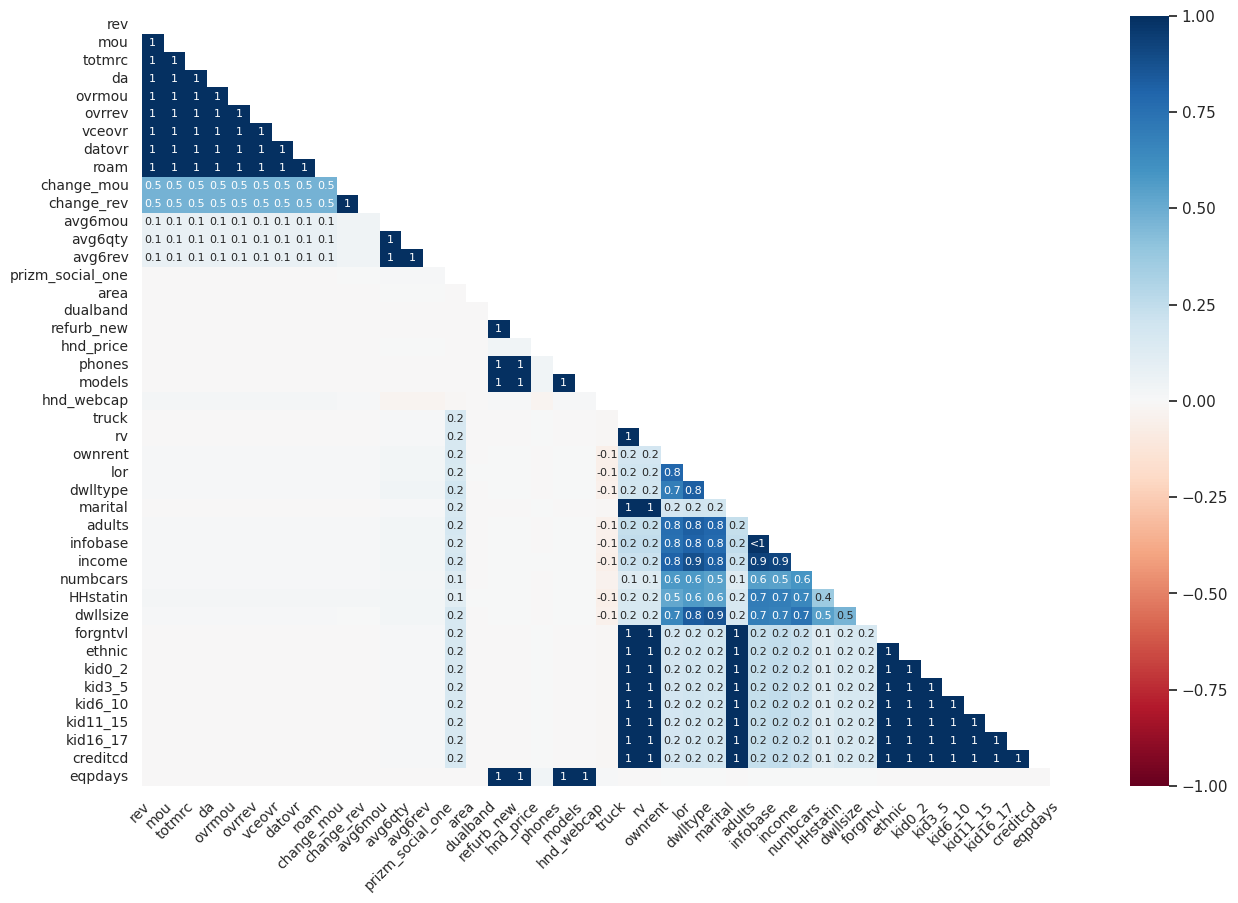

In [194]:
# chequeo de correlación de nulos con missingno

msno.heatmap(df_telecom, figsize=(15,10), fontsize=10);

In [195]:
# creamos una función para generar un dataframe con nulos y su % sobre el dataset
def listarNulos(dataset):

    df_stat = dataset.isnull().sum()[(dataset.isnull().sum()>0)].sort_values(ascending=False).to_frame()
    df_stat.rename(columns={0: 'Nulos'}, inplace = True)
    df_stat["Porcentaje"] = (df_stat["Nulos"]/dataset.shape[0]).astype(float).map("{:.2%}".format)

    return df_stat

In [196]:
listarNulos(df_telecom)

,Nulos,Porcentaje
numbcars,43568,48.41%
dwllsize,33764,37.52%
HHstatin,33032,36.70%
ownrent,29491,32.77%
dwlltype,27978,31.09%
lor,26502,29.45%
income,22196,24.66%
adults,20033,22.26%
infobase,19403,21.56%
hnd_webcap,9519,10.58%


In [197]:
# no hay filas enteramente duplicadas

df_telecom[df_telecom.duplicated(keep=False)]

,rev,mou,totmrc,da,ovrmou,ovrrev,vceovr,datovr,roam,change_mou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID


In [198]:
# no hay IDs duplicados

len(df_telecom['Customer_ID'].unique()) - len(df_telecom)

0

In [199]:
# El DataLoader es una clase auxiliar que va a cargar nuestros datasets
# Le suministramos la ruta del train/X y del test/dataset producción (prod) y nos devuelve los dos datasets
# También le tenemos que pasar la columna del target y del index
# Para que el objeto DataLoader distinga estas dos columnas

class DataLoader(object):
    '''
    DataLoader helps you import you train and test data and do some basic preprocessing on them.
    '''
    def __init__(self, train_path, test_path, train_columns, target, index):
        '''
        Constructor for the class.
        Needs the train and test path and train_columns (features), index and target column.
        '''
        self.train_path = train_path
        self.test_path = test_path

        self.train_columns = train_columns
        self.target = target
        self.index = index

    def _process_df(self, df):
        '''
        Converts the columns to upper, sets index and splits between X and y.
        '''
        df.columns = map(str.upper, df.columns)
        df.set_index(self.index, inplace = True)

        if self.target in df.columns:

            y = df[self.target]
            df.drop(self.target, axis = 1, inplace = True)
            df = df[self.train_columns]

            return df, y

        else:

            df = df[self.train_columns]

            return df, _

    def load_data(self):
        '''
        Loads the data and calls _process_df to X_train and X_test.
        '''
        X_train, y_train = self._process_df(pd.read_csv(self.train_path))

        X_test, _ = self._process_df(pd.read_csv(self.test_path))

        return X_train, y_train, X_test


# DataFrameReporter nos va a permitir hacer nuestro primer contacto con el dataset.

# Para las variables númericas hará un describe y contará los nulos que hay.
# Y para las variables categóricas hará un count de los nulos y nos dirá también
# el número de categorías únicas que hay.

# Al final se trata de una clase auxiliar que hará una parte del EDA.

class DataFrameReporter(object):
    '''
    Helper class that reports nulls and datatypes of train and test data
    '''
    def __init__(self, X_train, X_test, target_column):
        '''
        Constructor for the class.
        Needs train and test data and also the target column in train.
        '''
        self.X_train = X_train
        self.X_test = X_test
        self.target_column = target_column

    def analyze_X(self, X):
        '''
        Analyses the DataFrame you pass and returns a report of nulls, distribution and other goodies.
        '''

        if self.target_column in X.columns:
            X = X.drop(self.target_column, axis = 1)

        dtypes = X.dtypes.to_frame().rename(columns = {0:"Dtypes"})

        nulls_in_train = X.isnull().sum().to_frame().rename(columns = {0:"Absolute_nulls"})
        nulls_in_train["Relative_nulls"] = nulls_in_train["Absolute_nulls"]/X.shape[0]
        nulls_in_train["Relative_nulls"] = nulls_in_train["Relative_nulls"].apply(
            lambda number: round(number, 3) * 100
        )

        nulls_in_train = pd.concat([nulls_in_train, dtypes], axis = 1)
        nulls_in_train["Shape"] = X.shape[0]
        nulls_in_train = nulls_in_train[["Dtypes", "Shape", "Absolute_nulls", "Relative_nulls"]]

        describe_values_num = X.describe().T
        report_df = pd.concat([nulls_in_train, describe_values_num], axis = 1)

        object_columns = X.select_dtypes("object").columns
        unique_categories = {col:X[col].nunique() for col in object_columns}
        unique_cat_df = pd.DataFrame(
            data = unique_categories.values(),
            index = unique_categories.keys(),
            columns = ["Unique_category"]
        )

        report_df = pd.concat([report_df, unique_cat_df], axis = 1)

        report_df.fillna("", inplace = True)
        report_df.sort_values("Dtypes", ascending = True, inplace = True)

        return report_df

    def get_reports(self):
        '''
        Calls analyze_X method and returns report DataFrame for train and test.
        '''
        report_train = self.analyze_X(X = self.X_train)
        report_test = self.analyze_X(X = self.X_test)

        report_train["Origin"] = "X"
        report_test["Origin"] = "Prod"

        result = pd.concat([report_train, report_test])

        return result

In [200]:
set_config(transform_output = "pandas")

# Definimos nuestras variables globales
# En este caso, vamos a usar unas pocas columnas del dataframe a modo de ejemplo
# Es buena praxis definir este tipo de variables en un fichero json o bien al comienzo de un
# notebook/script

TRAIN_PATH = os.path.join(DATA_PATH, "telecom_churn_TRAINTEST.csv")
PRODUCTION_PATH = os.path.join(DATA_PATH, "telecom_churn_PREDICT.csv")

TARGET = "churn".upper()
INDEX = 'Customer_ID'.upper()

TRAIN_COLUMNS = [col.upper() for col in df_telecom.columns if col != "churn" and col != 'Customer_ID']

# Cargamos nuestros datasets con la clase auxiliar

X, y, X_prod = DataLoader(
    train_path = TRAIN_PATH,
    test_path = PRODUCTION_PATH,
    train_columns = TRAIN_COLUMNS,
    target = TARGET,
    index = INDEX
).load_data()

In [201]:
report = DataFrameReporter(
    pd.concat([X, y], axis = 1), X_prod, TARGET
).get_reports()

report[report['Origin'] == 'X']

,Dtypes,Shape,Absolute_nulls,Relative_nulls,count,mean,std,min,25%,50%,75%,max,Unique_category,Origin
MONTHS,int64,90000,0,0.0,90000.0,19.263856,9.149764,6.0,12.0,17.0,24.0,61.0,,X
AVG3MOU,int64,90000,0,0.0,90000.0,510.539844,524.737209,0.0,150.0,351.0,697.0,7716.0,,X
AVG3QTY,int64,90000,0,0.0,90000.0,178.227,191.398108,0.0,55.0,124.0,236.0,3909.0,,X
AVG3REV,int64,90000,0,0.0,90000.0,58.802889,46.476204,1.0,33.0,48.0,70.0,1593.0,,X
TOTCALLS,int64,90000,0,0.0,90000.0,2970.669433,3887.9212,0.0,929.0,1895.0,3605.0,98874.0,,X
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CREDITCD,object,90000,1451,1.6,,,,,,,,,2.0,X
PRIZM_SOCIAL_ONE,object,90000,6537,7.3,,,,,,,,,5.0,X
REFURB_NEW,object,90000,1,0.0,,,,,,,,,2.0,X
AREA,object,90000,40,0.0,,,,,,,,,19.0,X


# EDA: Analisis Exploratorio

## Distribución del target

In [202]:
df_telecom['churn'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 90000 entries, 0 to 89999
Series name: churn
Non-Null Count  Dtype
--------------  -----
90000 non-null  int64
dtypes: int64(1)
memory usage: 703.2 KB


In [203]:
df_telecom[['churn']].head()

,churn
0,1
1,0
2,1
3,0
4,0


In [204]:
# creamos una función para plotear categoricos

def countplot_categorica(dataset, column, size_chart = (5 , 5)):

    fig, (ax1) = plt.subplots(figsize=size_chart)

    counts = sns.countplot(data = dataset ,
                        x= dataset[column].sort_values(),
                        #y= dataset[column].sort_values(),
                        order = dataset[column].value_counts().index,
                        palette='Set2')

    #plt.xticks(rotation=90)

    for bars in counts.containers:
        counts.bar_label(bars);

    #dis.set(xlabel = 'Conteo' , ylabel = column , title='Conteo de ' +  column);
    counts.set(ylabel = 'Conteo' , xlabel = column , title='Conteo de ' +  column);

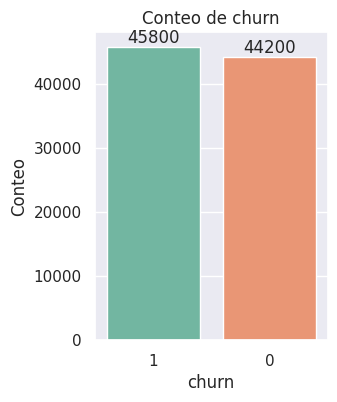

In [205]:
# el Target esta balanceado en casi un 50% de ocurrencias en cada uno de los casas. No hay problema de desbalanceo

countplot_categorica(df_telecom,'churn', size_chart = (3 , 4))

In [206]:
print(df_telecom['churn'].value_counts(dropna=False))

print('')
print('')

print(df_telecom['churn'].value_counts(dropna=False, normalize=True).mul(100).round(2).astype(str) + '%')

1    45800
0    44200
Name: churn, dtype: int64


1    50.89%
0    49.11%
Name: churn, dtype: object


In [207]:
# no hay nulos en el Target

df_telecom['churn'].isnull().sum()

0

## Analisis Univariable

* Distribucion de cada variable

In [208]:
# Función para lista de variables

target = ['churn']
index = ['Customer_ID']

def obtener_lista_variables(dataset):

  lista_numericas = []
  lista_boolean = []
  lista_categoricas = []

  for i in dataset:
    if ((dataset[i].dtype.kind == 'i') or (dataset[i].dtype.kind == 'f')) and i not in target and i not in index\
    and len(dataset[i].unique()) != 2:
      lista_numericas.append(i)

    elif ((dataset[i].dtype.kind == 'i') or (dataset[i].dtype.kind == 'f') or (dataset[i].dtype.kind == 'b')) and i not in target and i not in index\
    and len(dataset[i].unique()) == 2:
      lista_boolean.append(i)

    elif (dataset[i].dtype.kind == 'O') and i not in target and i not in index:
      lista_categoricas.append(i)

  return lista_numericas, lista_boolean, lista_categoricas

In [209]:
lnum, lbool, lcat = obtener_lista_variables(df_telecom)

In [210]:
print(lnum)

['rev', 'mou', 'totmrc', 'da', 'ovrmou', 'ovrrev', 'vceovr', 'datovr', 'roam', 'change_mou', 'change_rev', 'drop_vce', 'drop_dat', 'blck_vce', 'blck_dat', 'unan_vce', 'unan_dat', 'plcd_vce', 'plcd_dat', 'recv_vce', 'recv_sms', 'comp_vce', 'comp_dat', 'custcare', 'ccrndmou', 'cc_mou', 'inonemin', 'threeway', 'mou_cvce', 'mou_cdat', 'mou_rvce', 'owylis_vce', 'mouowylisv', 'iwylis_vce', 'mouiwylisv', 'peak_vce', 'peak_dat', 'mou_peav', 'mou_pead', 'opk_vce', 'opk_dat', 'mou_opkv', 'mou_opkd', 'drop_blk', 'attempt', 'complete', 'callfwdv', 'callwait', 'months', 'uniqsubs', 'actvsubs', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'hnd_price', 'phones', 'models', 'truck', 'rv', 'lor', 'adults', 'income', 'numbcars', 'forgntvl', 'eqpdays']


In [211]:
print(lcat)

['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']


In [212]:
print(lbool)

[]


* Analisis univariable de columnas numericas

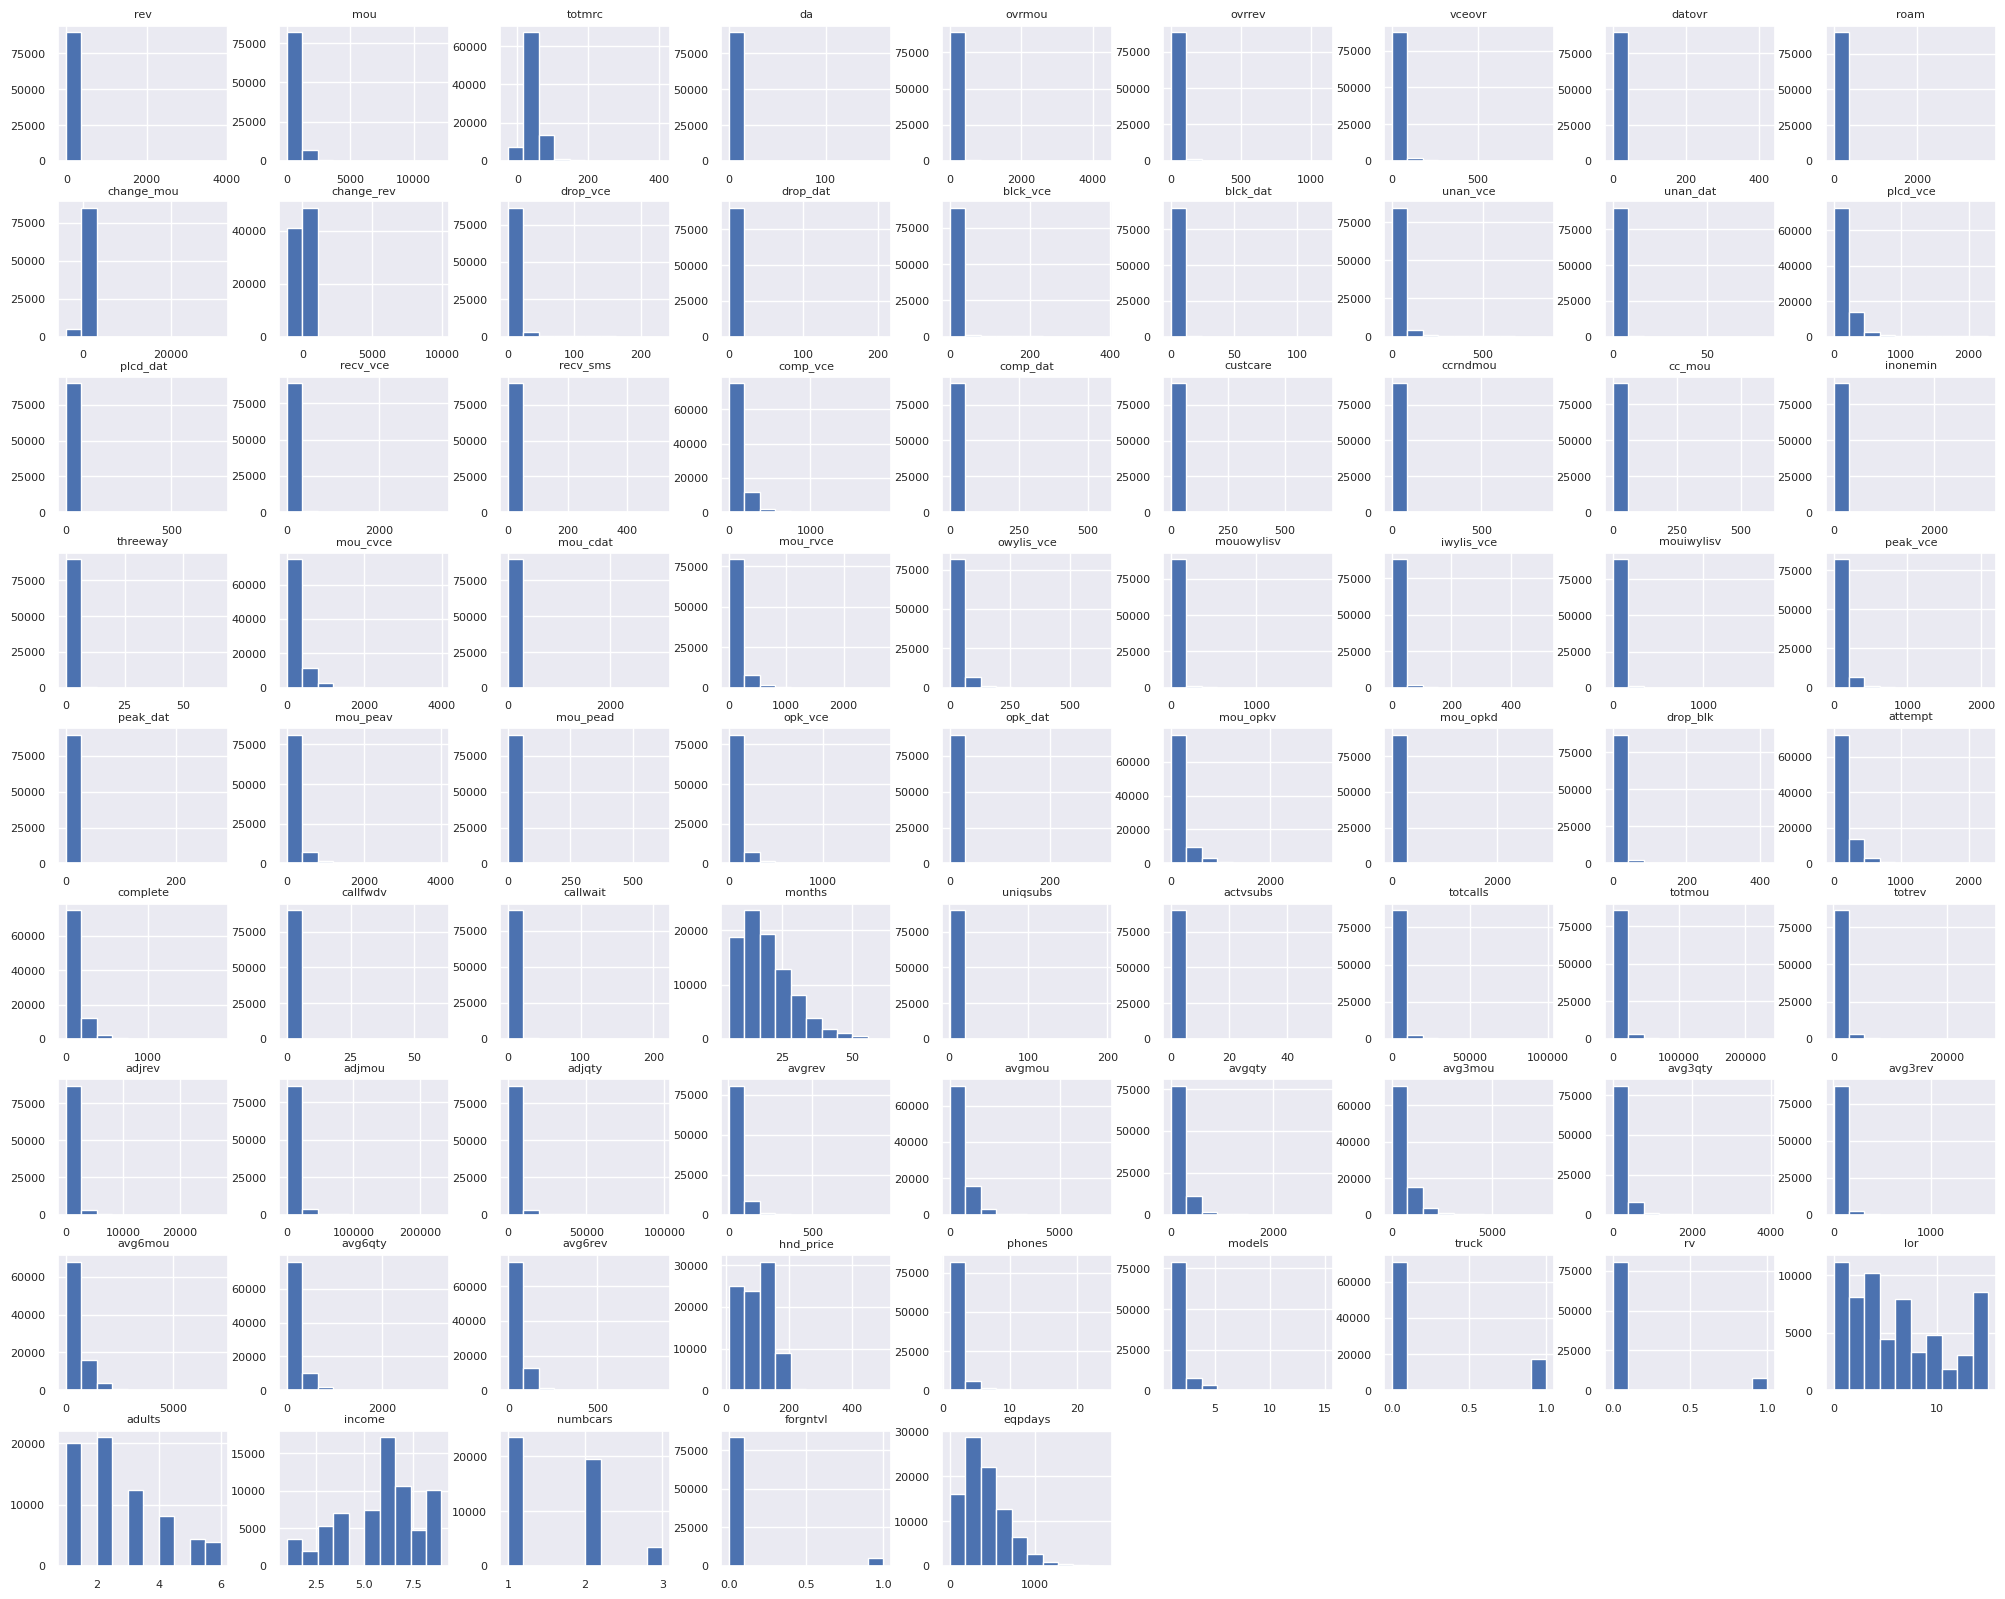

In [213]:
fig = df_telecom[lnum].hist(figsize=(25,20), xlabelsize=8, ylabelsize=8);
[x.title.set_size(8) for x in fig.ravel()];

In [214]:
df_telecom[lnum].describe()

,rev,mou,totmrc,da,ovrmou,ovrrev,vceovr,datovr,roam,change_mou,...,phones,models,truck,rv,lor,adults,income,numbcars,forgntvl,eqpdays
count,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89866.000000,89405.000000,...,89999.000000,89999.000000,88549.000000,88549.000000,63498.000000,69967.000000,67804.000000,46432.000000,88549.000000,89999.000000
mean,58.312895,504.277946,45.880669,0.877813,40.798976,13.289932,13.046046,0.240786,1.308197,-13.786987,...,1.802987,1.556184,0.197190,0.086867,6.180856,2.538197,5.809274,1.568896,0.059255,402.419438
std,46.084103,516.170057,23.370435,2.173665,96.970619,30.123282,29.719581,3.012631,15.374215,271.624916,...,1.319121,0.900798,0.397879,0.281642,4.741242,1.452650,2.176928,0.628308,0.236103,252.821660
min,-5.862500,0.000000,-26.915000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3875.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,-5.000000
25%,33.027500,148.500000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-85.750000,...,1.000000,1.000000,0.000000,0.000000,2.000000,1.000000,4.000000,1.000000,0.000000,227.000000
50%,47.667500,349.000000,44.990000,0.247500,2.500000,0.900000,0.600000,0.000000,0.000000,-6.500000,...,1.000000,1.000000,0.000000,0.000000,5.000000,2.000000,6.000000,1.000000,0.000000,359.000000
75%,70.193750,689.000000,59.990000,0.742500,41.250000,13.912500,13.562500,0.000000,0.257500,61.250000,...,2.000000,2.000000,0.000000,0.000000,9.000000,3.000000,7.000000,2.000000,0.000000,547.000000
max,3843.262500,12206.750000,409.990000,159.390000,4320.750000,1102.400000,896.087500,423.540000,3685.200000,31219.250000,...,24.000000,15.000000,1.000000,1.000000,15.000000,6.000000,9.000000,3.000000,1.000000,1812.000000


In [215]:
def box_numerica_all(dataset, lista_numerica, size_fig = (30 , 30)):

    n_cols = 4
    n_rows = math.ceil(len(lista_numerica)/n_cols)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(size_fig))

    for i in lista_numerica:
        row_plot = lista_numerica.index(i) // n_cols
        col_plot = lista_numerica.index(i) % n_cols
        title_plot = df_desc[df_desc["Variable"]==i][" Description"].values[0]

        box = sns.boxplot(data=dataset,
                            x=i,
                            ax=axes[row_plot,col_plot],
                            palette='Set2')

        box.set_title(title_plot, fontsize=11)
        #dis.set_xticklabels(dis.get_xticklabels(), rotation=45, ha='right', fontsize=11)

        plt.tight_layout()

        #for bars in counts.containers:
        #    counts.bar_label(bars);

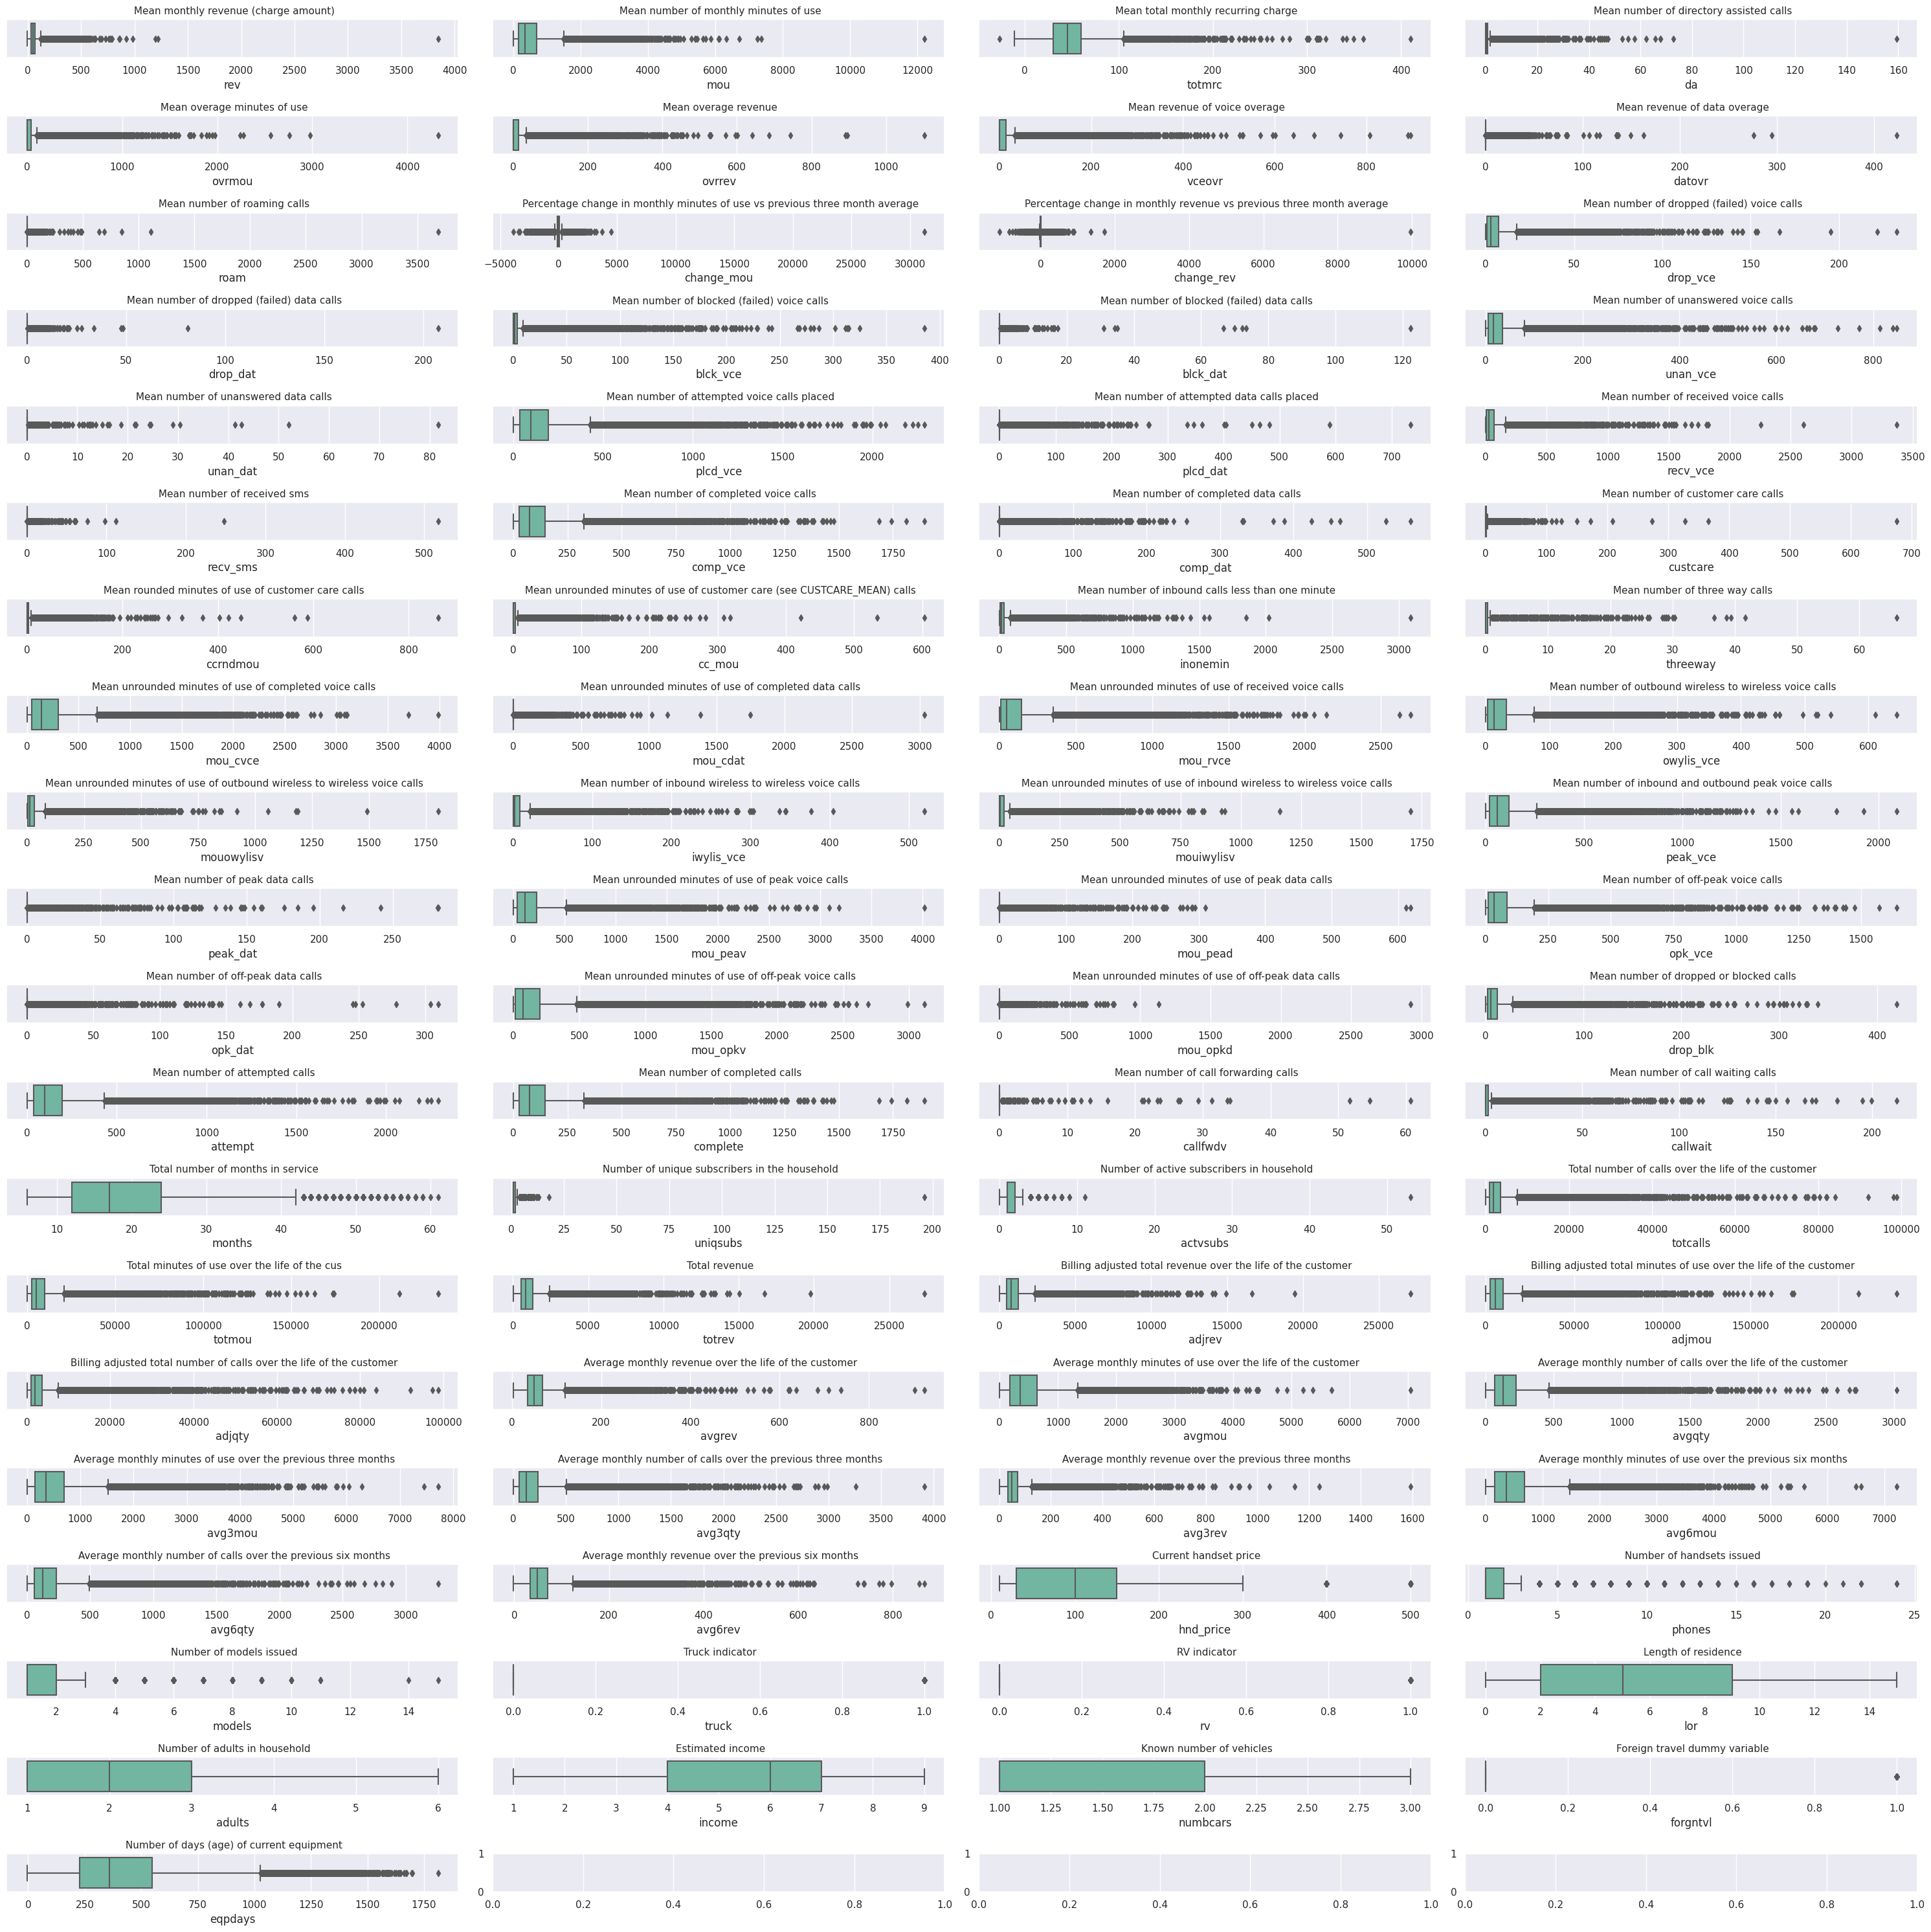

In [216]:
box_numerica_all(df_telecom, lnum, size_fig = (30 , 30))

In [217]:
# podemos ver en los histogramas que hay columnas que son realmente boolean en lugar de númericas,
# por lo que las identificamos paraa analizarlos luego

boolean_instead_of_numeric = ['truck','rv','forgntvl']

for i in boolean_instead_of_numeric:

    print(df_telecom[i].value_counts(dropna=False))
    print('')

0.0    71088
1.0    17461
NaN     1451
Name: truck, dtype: int64

0.0    80857
1.0     7692
NaN     1451
Name: rv, dtype: int64

0.0    83302
1.0     5247
NaN     1451
Name: forgntvl, dtype: int64



In [218]:
# actualizamos nuestra lista de variables

for i in boolean_instead_of_numeric:

    lnum.remove(i)
    lbool.append(i)

print(lnum)
print(lbool)

['rev', 'mou', 'totmrc', 'da', 'ovrmou', 'ovrrev', 'vceovr', 'datovr', 'roam', 'change_mou', 'change_rev', 'drop_vce', 'drop_dat', 'blck_vce', 'blck_dat', 'unan_vce', 'unan_dat', 'plcd_vce', 'plcd_dat', 'recv_vce', 'recv_sms', 'comp_vce', 'comp_dat', 'custcare', 'ccrndmou', 'cc_mou', 'inonemin', 'threeway', 'mou_cvce', 'mou_cdat', 'mou_rvce', 'owylis_vce', 'mouowylisv', 'iwylis_vce', 'mouiwylisv', 'peak_vce', 'peak_dat', 'mou_peav', 'mou_pead', 'opk_vce', 'opk_dat', 'mou_opkv', 'mou_opkd', 'drop_blk', 'attempt', 'complete', 'callfwdv', 'callwait', 'months', 'uniqsubs', 'actvsubs', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'hnd_price', 'phones', 'models', 'lor', 'adults', 'income', 'numbcars', 'eqpdays']
['truck', 'rv', 'forgntvl']


In [219]:
df_telecom[lnum].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 74 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rev         89866 non-null  float64
 1   mou         89866 non-null  float64
 2   totmrc      89866 non-null  float64
 3   da          89866 non-null  float64
 4   ovrmou      89866 non-null  float64
 5   ovrrev      89866 non-null  float64
 6   vceovr      89866 non-null  float64
 7   datovr      89866 non-null  float64
 8   roam        89866 non-null  float64
 9   change_mou  89405 non-null  float64
 10  change_rev  89405 non-null  float64
 11  drop_vce    90000 non-null  float64
 12  drop_dat    90000 non-null  float64
 13  blck_vce    90000 non-null  float64
 14  blck_dat    90000 non-null  float64
 15  unan_vce    90000 non-null  float64
 16  unan_dat    90000 non-null  float64
 17  plcd_vce    90000 non-null  float64
 18  plcd_dat    90000 non-null  float64
 19  recv_vce    90000 non-nul

In [220]:
listarNulos(df_telecom[lnum])

,Nulos,Porcentaje
numbcars,43568,48.41%
lor,26502,29.45%
income,22196,24.66%
adults,20033,22.26%
avg6mou,1407,1.56%
avg6rev,1407,1.56%
avg6qty,1407,1.56%
hnd_price,704,0.78%
change_mou,595,0.66%
change_rev,595,0.66%


In [221]:
# a primera vista, no hay columnas irrelevantes o que no sean variables
# aunque lo manejaremos de manera automatizada más adelante

for i in lnum:
    print(df_telecom[i].value_counts(dropna=False))
    print('')
    print('--------------')
    print('')

29.9900     2015
34.9900     1232
10.0000      832
30.0000      782
30.2600      718
            ... 
110.1900       1
216.2000       1
91.3450        1
92.1825        1
72.7450        1
Name: rev, Length: 35161, dtype: int64

--------------

0.000000       1493
NaN             134
0.250000        120
0.500000         84
0.750000         74
               ... 
2158.750000       1
3574.750000       1
1879.000000       1
2.666667          1
2022.250000       1
Name: mou, Length: 9181, dtype: int64

--------------

44.9900    9600
29.9900    8298
59.9900    7624
39.9900    7248
10.0000    5501
           ... 
48.6950       1
5.6475        1
25.8250       1
89.7775       1
34.9650       1
Name: totmrc, Length: 7677, dtype: int64

--------------

0.0000     43789
0.2475     11924
0.4950      6978
0.7425      4794
0.9900      3549
           ...  
65.8350        1
36.1350        1
31.4325        1
40.5900        1
34.6500        1
Name: da, Length: 164, dtype: int64

--------------

0.00    

In [222]:
# hay ciertas variables que tienen un valor mínimo negativo
# por lo que se analizan más en detalle

df_min_less_than_zero = df_telecom[lnum].describe().loc[['min']]<0

lista_columnas_min_menor_que_zero = []

for i in df_min_less_than_zero.columns:

    if df_min_less_than_zero[i].unique() == True:
        lista_columnas_min_menor_que_zero.append(i)
    else:
        pass

lista_columnas_min_menor_que_zero

['rev', 'totmrc', 'change_mou', 'change_rev', 'avg6rev', 'eqpdays']

In [223]:
# las columnas rev, totmrc, change_mou, change_mou y avg6rev pueden tener valores negativos
# a causa de refunds pero la columna de eqpdays no tiene sentido contener valores negativos
# ya que un móvil no puede tener una antiguedad negativa

df_telecom[lista_columnas_min_menor_que_zero ].describe().round(1)

,rev,totmrc,change_mou,change_rev,avg6rev,eqpdays
count,89866.0,89866.0,89405.0,89405.0,88593.0,89999.0
mean,58.3,45.9,-13.8,-1.1,58.3,402.4
std,46.1,23.4,271.6,50.6,40.5,252.8
min,-5.9,-26.9,-3875.0,-1107.7,-2.0,-5.0
25%,33.0,30.0,-85.8,-7.2,34.0,227.0
50%,47.7,45.0,-6.5,-0.3,49.0,359.0
75%,70.2,60.0,61.2,1.5,70.0,547.0
max,3843.3,410.0,31219.2,9963.7,866.0,1812.0


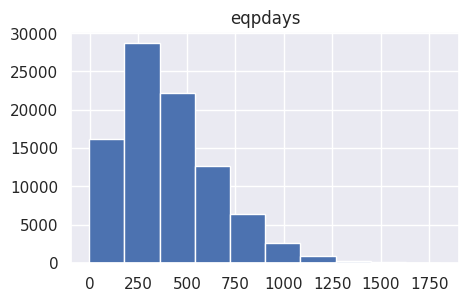

In [224]:
df_telecom['eqpdays'].hist(figsize=(5,3)).set_title('eqpdays');


In [225]:
# hay 102 regsitros con valores negativos para eqpdays que los trataremos más adelante

df_telecom[df_telecom['eqpdays']<0]

,rev,mou,totmrc,da,ovrmou,ovrrev,vceovr,datovr,roam,change_mou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
190,180.2250,3559.00,149.990,11.3850,99.00,14.8500,14.8500,0.000,0.000,-149.00,...,0.0,Z,U,U,U,U,U,N,-3.0,1000191
573,81.2250,227.75,59.990,1.2375,0.00,0.0000,0.0000,0.000,0.000,30.25,...,0.0,U,U,U,U,U,U,Y,-3.0,1000574
810,36.3400,247.25,29.990,2.4750,7.25,2.9000,2.9000,0.000,0.975,153.75,...,0.0,S,U,U,U,U,U,Y,-1.0,1000811
1371,77.1625,413.25,70.000,0.7425,0.00,0.0000,0.0000,0.000,1.920,208.75,...,0.0,N,U,U,U,U,U,Y,-1.0,1001372
3631,45.5100,666.00,44.990,0.0000,26.00,9.1000,9.1000,0.000,0.320,35.00,...,0.0,Z,U,U,U,U,U,N,-1.0,1003632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88466,7.5000,67.00,10.000,0.0000,0.00,0.0000,0.0000,0.000,0.000,12.00,...,0.0,S,U,U,U,U,U,Y,-1.0,1088467
88588,326.0250,4654.25,169.990,34.6500,708.25,106.2375,106.2375,0.000,0.000,86.75,...,0.0,N,U,U,U,U,U,Y,-3.0,1088589
89262,243.0175,2149.25,129.365,9.9000,375.75,150.3000,150.3000,0.000,0.000,-626.25,...,0.0,U,U,U,U,U,U,Y,-4.0,1089263
89348,120.3575,3381.00,104.990,0.7425,43.00,15.0500,15.0500,0.000,0.000,384.00,...,0.0,Z,U,U,U,U,U,N,-3.0,1089349


* Analisis univariable de columnas categoricas

In [226]:
print(lcat)

['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']


In [227]:
df_telecom[lcat].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   new_cell          90000 non-null  object
 1   crclscod          90000 non-null  object
 2   asl_flag          90000 non-null  object
 3   prizm_social_one  83463 non-null  object
 4   area              89960 non-null  object
 5   dualband          89999 non-null  object
 6   refurb_new        89999 non-null  object
 7   hnd_webcap        80481 non-null  object
 8   ownrent           60509 non-null  object
 9   dwlltype          62022 non-null  object
 10  marital           88549 non-null  object
 11  infobase          70597 non-null  object
 12  HHstatin          56968 non-null  object
 13  dwllsize          56236 non-null  object
 14  ethnic            88549 non-null  object
 15  kid0_2            88549 non-null  object
 16  kid3_5            88549 non-null  object
 17  kid6_10     

In [228]:
df_telecom[lcat].describe()

,new_cell,crclscod,asl_flag,prizm_social_one,area,dualband,refurb_new,hnd_webcap,ownrent,dwlltype,...,infobase,HHstatin,dwllsize,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd
count,90000,90000,90000,83463,89960,89999,89999,80481,60509,62022,...,70597,56968,56236,88549,88549,88549,88549,88549,88549,88549
unique,3,54,2,5,19,4,2,3,2,2,...,1,6,15,16,2,2,2,2,2,2
top,U,AA,N,S,NEW YORK CITY AREA,Y,N,WCMB,O,S,...,M,C,A,N,U,U,U,U,U,Y
freq,58812,34152,79401,29203,10293,65977,76624,67396,58729,44521,...,70597,36093,43118,30400,84938,84308,81196,80497,79419,61716


In [229]:
listarNulos(df_telecom[lcat])

,Nulos,Porcentaje
dwllsize,33764,37.52%
HHstatin,33032,36.70%
ownrent,29491,32.77%
dwlltype,27978,31.09%
infobase,19403,21.56%
hnd_webcap,9519,10.58%
prizm_social_one,6537,7.26%
marital,1451,1.61%
ethnic,1451,1.61%
kid0_2,1451,1.61%


In [230]:
def countplot_categorica_all(dataset, lista_categoricas, size_fig = (30 , 30)):

    n_cols = 4
    n_rows = math.ceil(len(lista_categoricas)/n_cols)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(size_fig))
    lista_categoricas_ord_unique = dataset[lista_categoricas].describe().T.sort_values(by="unique").index.to_list()

    data_show = dataset[lista_categoricas_ord_unique]

    for i, col in enumerate(data_show):
        row_plot = i // n_cols
        col_plot = i % n_cols
        title_plot = df_desc[df_desc["Variable"]==col][" Description"].values[0]

        #counts = sns.countplot(x=col, data=data_show, ax=axes[row_plot,col_plot])
        counts = sns.countplot(data = data_show ,
                                y= data_show[col].sort_values(),
                                order = data_show[col].value_counts().index,
                                ax=axes[row_plot,col_plot],
                                palette='Set2')

        counts.set_title(title_plot, fontsize=11)
        counts.set_xticklabels(counts.get_xticklabels(), rotation=45, ha='right', fontsize=11)
        counts.set_xlabel(xlabel = 'count', fontsize=11)
        counts.set_yticklabels(counts.get_yticklabels(), fontsize=11)
        counts.set_ylabel(ylabel=col, fontsize=11)

        #plt.xticks(rotation=90)
        plt.tight_layout()

        for bars in counts.containers:
            counts.bar_label(bars, fontsize=11);

        #counts.set(xlabel = 'Conteo' , ylabel = column , title='Conteo de ' +  column);

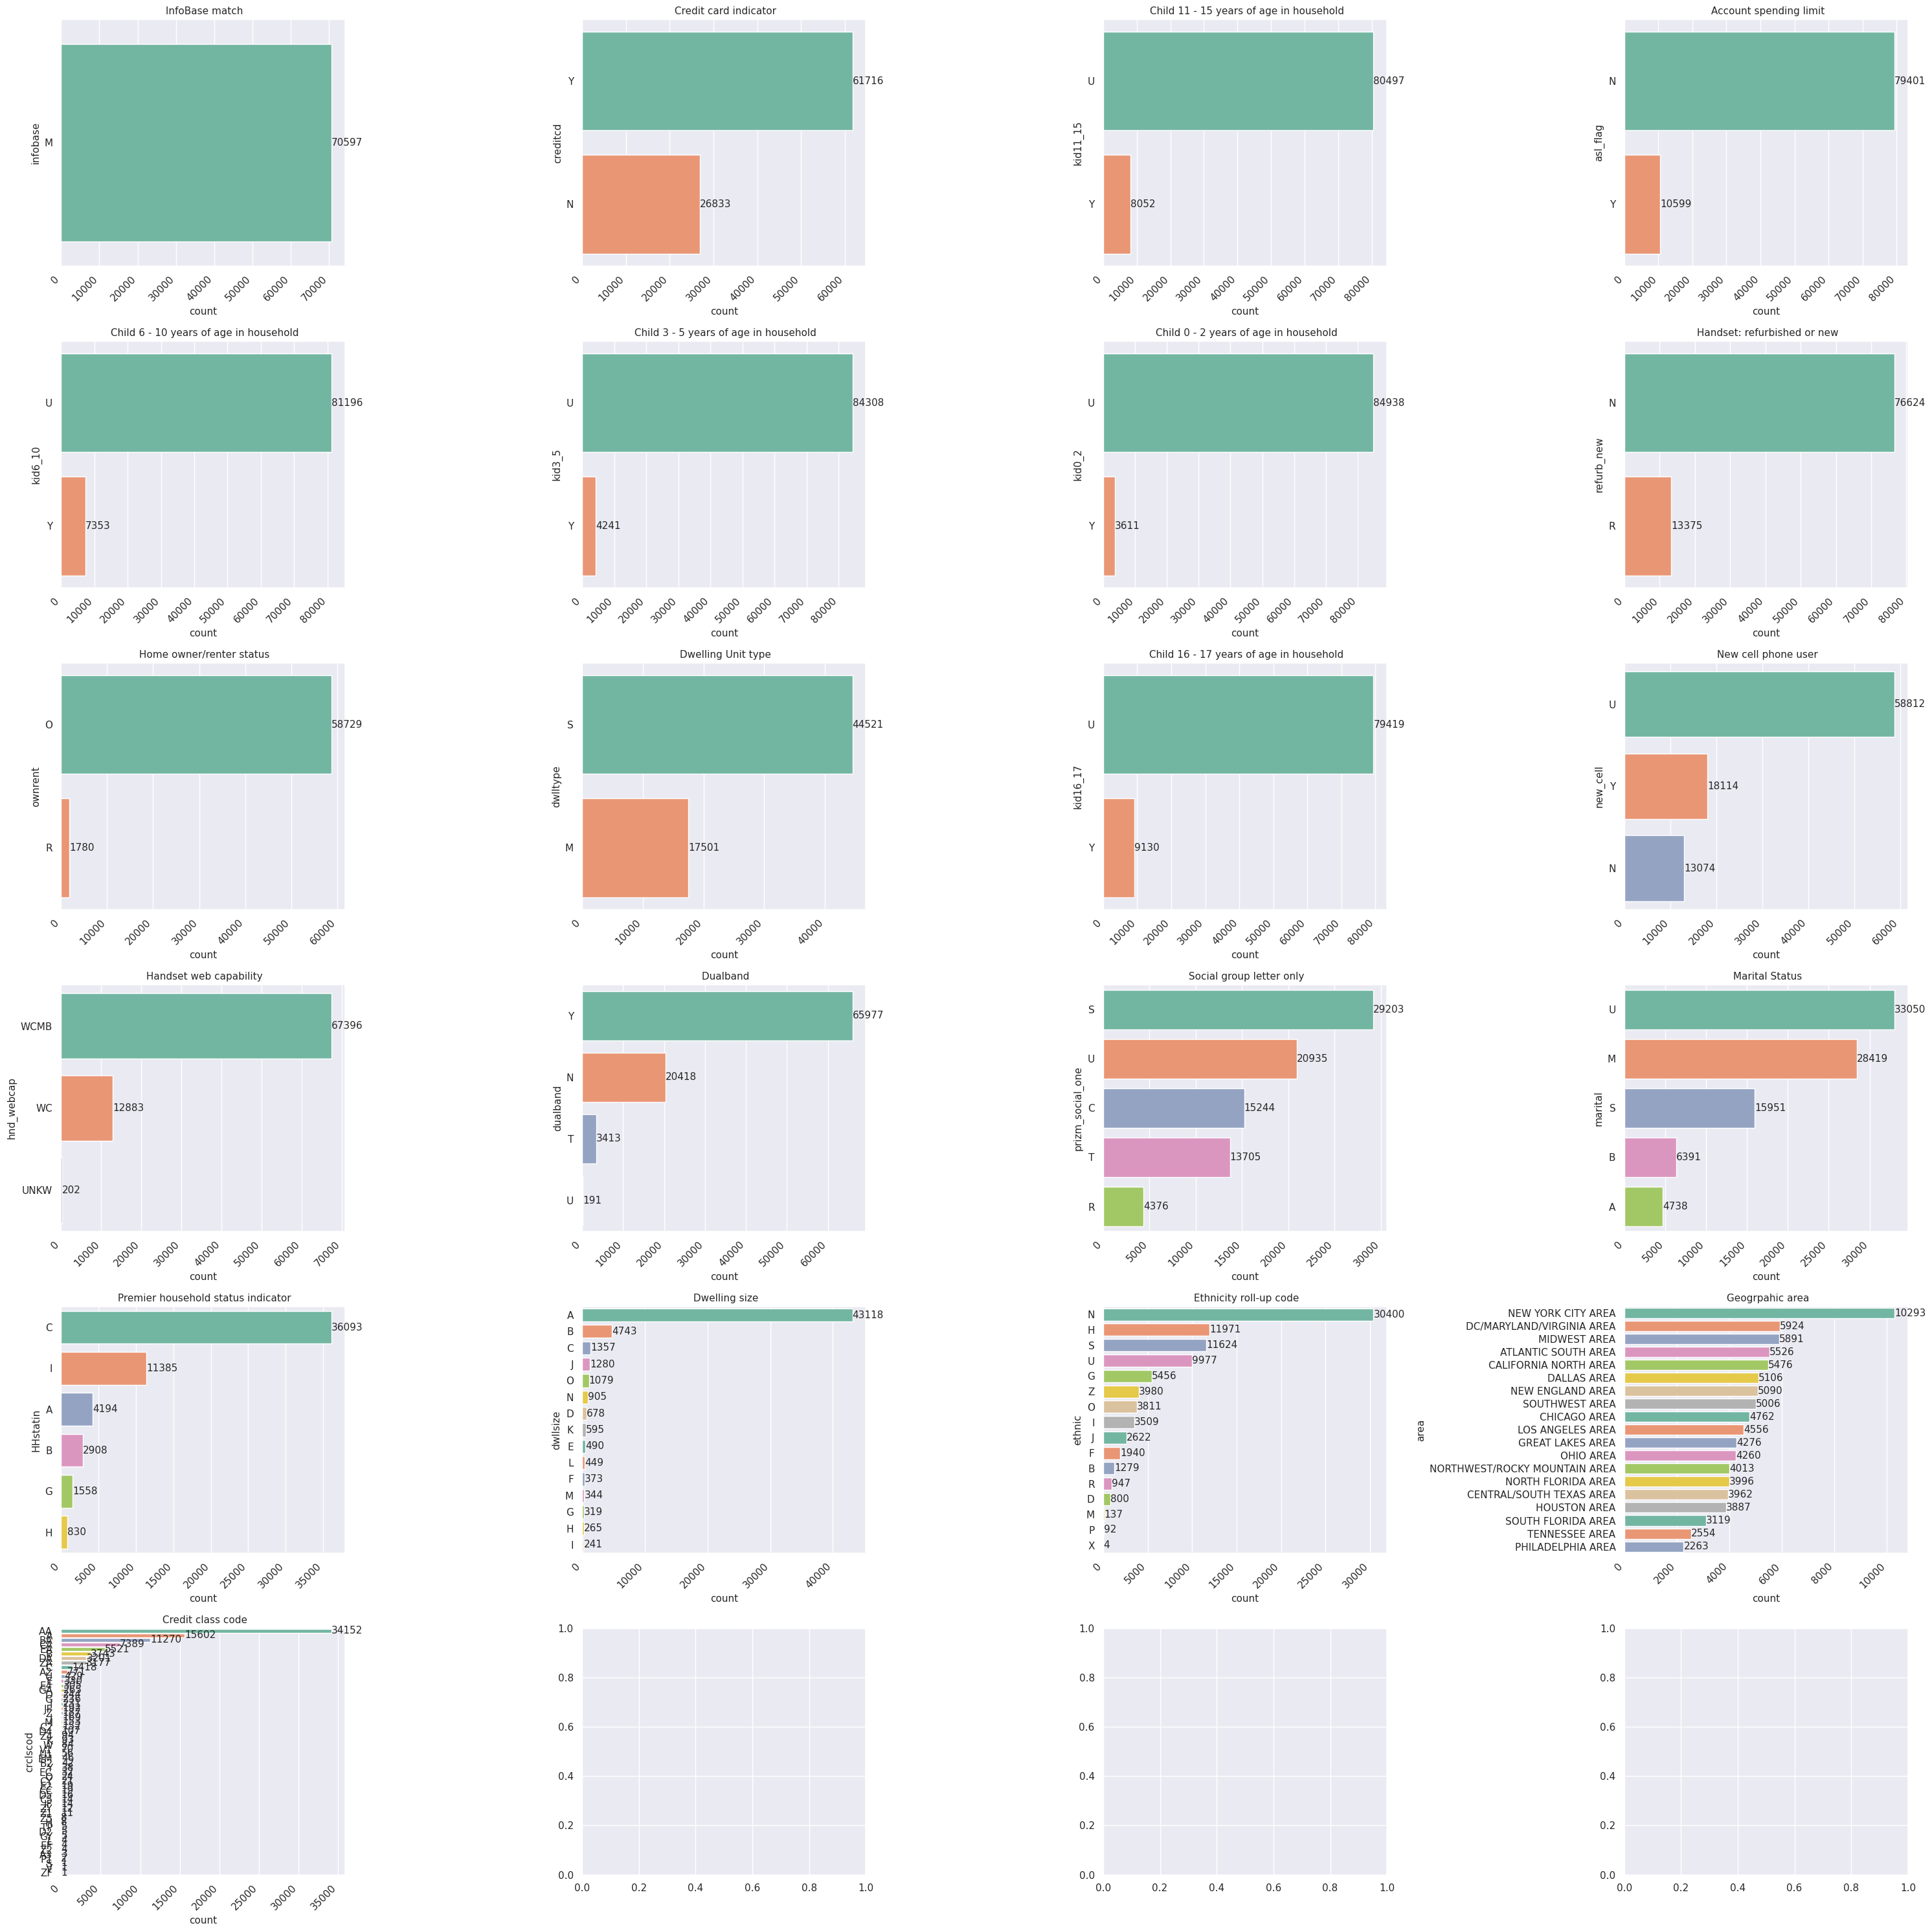

In [231]:
countplot_categorica_all(df_telecom, lcat)

In [232]:
# la columna infobase no parece ser muy relevante y variable,
# la analizamos más a fondo

print(df_desc[df_desc['Variable'] == 'infobase'])

df_telecom['infobase'].value_counts(dropna=False)

    Variable      Description    Tipo
85  infobase   InfoBase match  object


M      70597
NaN    19403
Name: infobase, dtype: int64

In [233]:
# dropeamos esta columna de todos nuestros dfs y listas

df_telecom.drop('infobase', axis='columns', inplace=True)
df_desc.drop(85, inplace=True)
df_desc.reset_index(inplace=True)
df_desc.drop('index', axis='columns', inplace=True)
lcat.remove('infobase')

print("Se han eliminado las siguientes columnas: 'infobase'")

Se han eliminado las siguientes columnas: 'infobase'


In [234]:
# podemos ver en los graficos que hay columnas que son realmente boolean en lugar de categoricas,
# por lo que las identificamos paraa analizarlos luego

boolean_instead_of_categoric = ['creditcd', 'asl_flag']

for i in boolean_instead_of_categoric:

    print(df_telecom[i].value_counts(dropna=False))
    print('')

Y      61716
N      26833
NaN     1451
Name: creditcd, dtype: int64

N    79401
Y    10599
Name: asl_flag, dtype: int64



In [235]:
# actualizamos nuestra lista de variables

for i in boolean_instead_of_categoric:

    lcat.remove(i)
    lbool.append(i)

print(lcat)
print(lbool)

['new_cell', 'crclscod', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17']
['truck', 'rv', 'forgntvl', 'creditcd', 'asl_flag']


* Analisis univariable de columnas booleanas

In [236]:
print(lbool)

['truck', 'rv', 'forgntvl', 'creditcd', 'asl_flag']


In [237]:
df_telecom[lbool].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   truck     88549 non-null  float64
 1   rv        88549 non-null  float64
 2   forgntvl  88549 non-null  float64
 3   creditcd  88549 non-null  object 
 4   asl_flag  90000 non-null  object 
dtypes: float64(3), object(2)
memory usage: 3.4+ MB


In [238]:
df_telecom[lbool].describe(include='all')

,truck,rv,forgntvl,creditcd,asl_flag
count,88549.000000,88549.000000,88549.000000,88549,90000
unique,NaN,NaN,NaN,2,2
top,NaN,NaN,NaN,Y,N
freq,NaN,NaN,NaN,61716,79401
mean,0.197190,0.086867,0.059255,NaN,NaN
std,0.397879,0.281642,0.236103,NaN,NaN
min,0.000000,0.000000,0.000000,NaN,NaN
25%,0.000000,0.000000,0.000000,NaN,NaN
50%,0.000000,0.000000,0.000000,NaN,NaN
75%,0.000000,0.000000,0.000000,NaN,NaN


In [239]:
listarNulos(df_telecom[lbool])

,Nulos,Porcentaje
truck,1451,1.61%
rv,1451,1.61%
forgntvl,1451,1.61%
creditcd,1451,1.61%


In [240]:
def countplot_bool_all(dataset, lista_boolean, size_fig = (30 , 30)):

    n_cols = 4
    n_rows = math.ceil(len(lista_boolean)/n_cols)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(size_fig))
    #lista_categoricas_ord_unique = dataset[lista_categoricas].describe().T.sort_values(by="unique").index.to_list()

    data_show = dataset[lista_boolean]

    for i, col in enumerate(data_show):
        row_plot = i // n_cols
        col_plot = i % n_cols
        title_plot = df_desc[df_desc["Variable"]==col][" Description"].values[0]

        #counts = sns.countplot(x=col, data=data_show, ax=axes[row_plot,col_plot])
        counts = sns.countplot(data = data_show ,
                                y= data_show[col].sort_values(),
                                order = data_show[col].value_counts().index,
                                ax=axes[row_plot,col_plot],
                                palette='Set2')

        counts.set_title(title_plot, fontsize=11)
        counts.set_xticklabels(counts.get_xticklabels(), rotation=45, ha='right', fontsize=11)
        counts.set_xlabel(xlabel = 'count', fontsize=11)
        counts.set_yticklabels(counts.get_yticklabels(), fontsize=11)
        counts.set_ylabel(ylabel=col, fontsize=11)

        #plt.xticks(rotation=90)
        plt.tight_layout()

        for bars in counts.containers:
            counts.bar_label(bars, fontsize=11);

        #counts.set(xlabel = 'Conteo' , ylabel = column , title='Conteo de ' +  column);

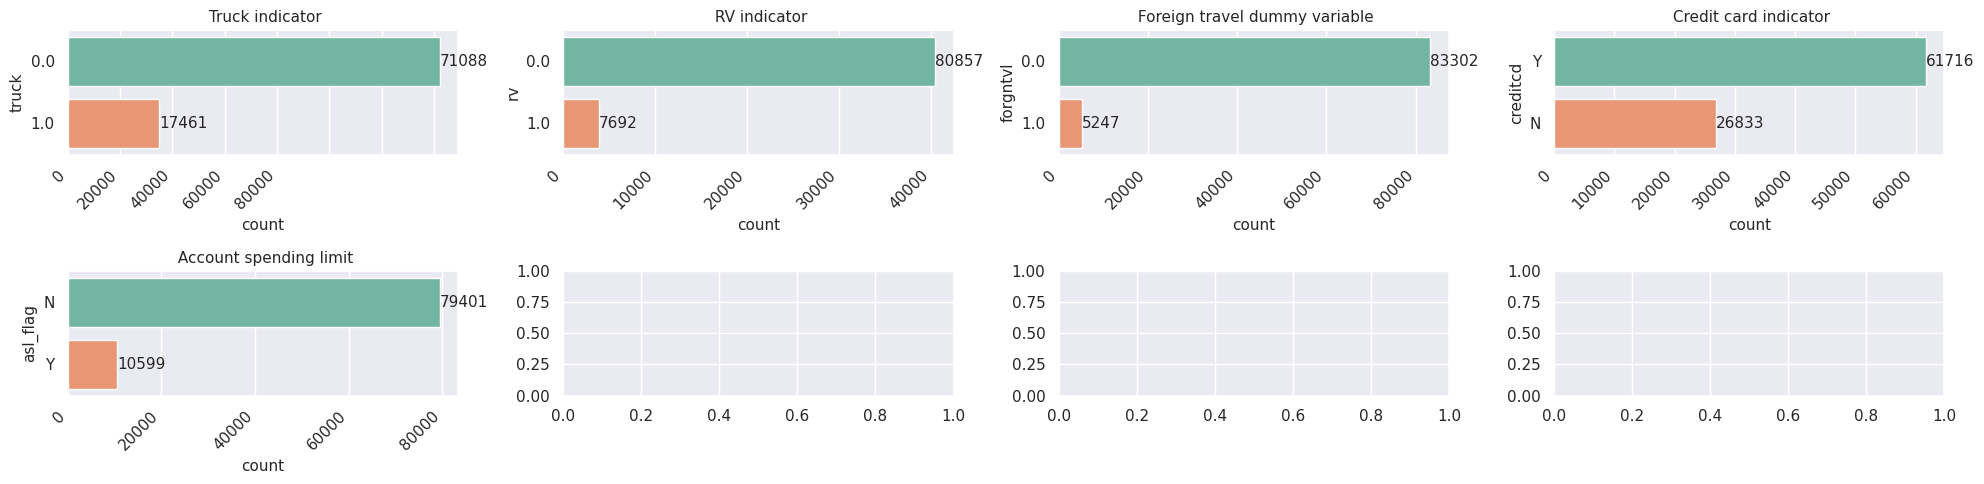

In [241]:
# no hay variables por tratar por el momento en cuanto a relevancia

countplot_bool_all(df_telecom, lbool, size_fig = (20, 5))

## Analisis Variable-Target

* Relacion target-variable

In [242]:
def kdeplot_numerica_all_vs_target(dataset, lista_numerica, target, size_fig = (30 , 30)):

    n_cols = 4
    n_rows = math.ceil(len(lista_numerica)/n_cols)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(size_fig))

    for i in lista_numerica:
        row_plot = lista_numerica.index(i) // n_cols
        col_plot = lista_numerica.index(i) % n_cols
        title_plot = df_desc[df_desc["Variable"]==i][" Description"].values[0]
        ax=axes[row_plot,col_plot]
        kde = sns.kdeplot(data=dataset,
                            x=i,
                            hue=target,
                            fill='True',
                            ax=ax,
                            palette='Set2')

        kde.set_title(title_plot, fontsize=11)
        kde.set_xticklabels(kde.get_xticklabels(), rotation=45, ha='right', fontsize=11)

    plt.tight_layout()

        #for bars in counts.containers:
        #    counts.bar_label(bars);

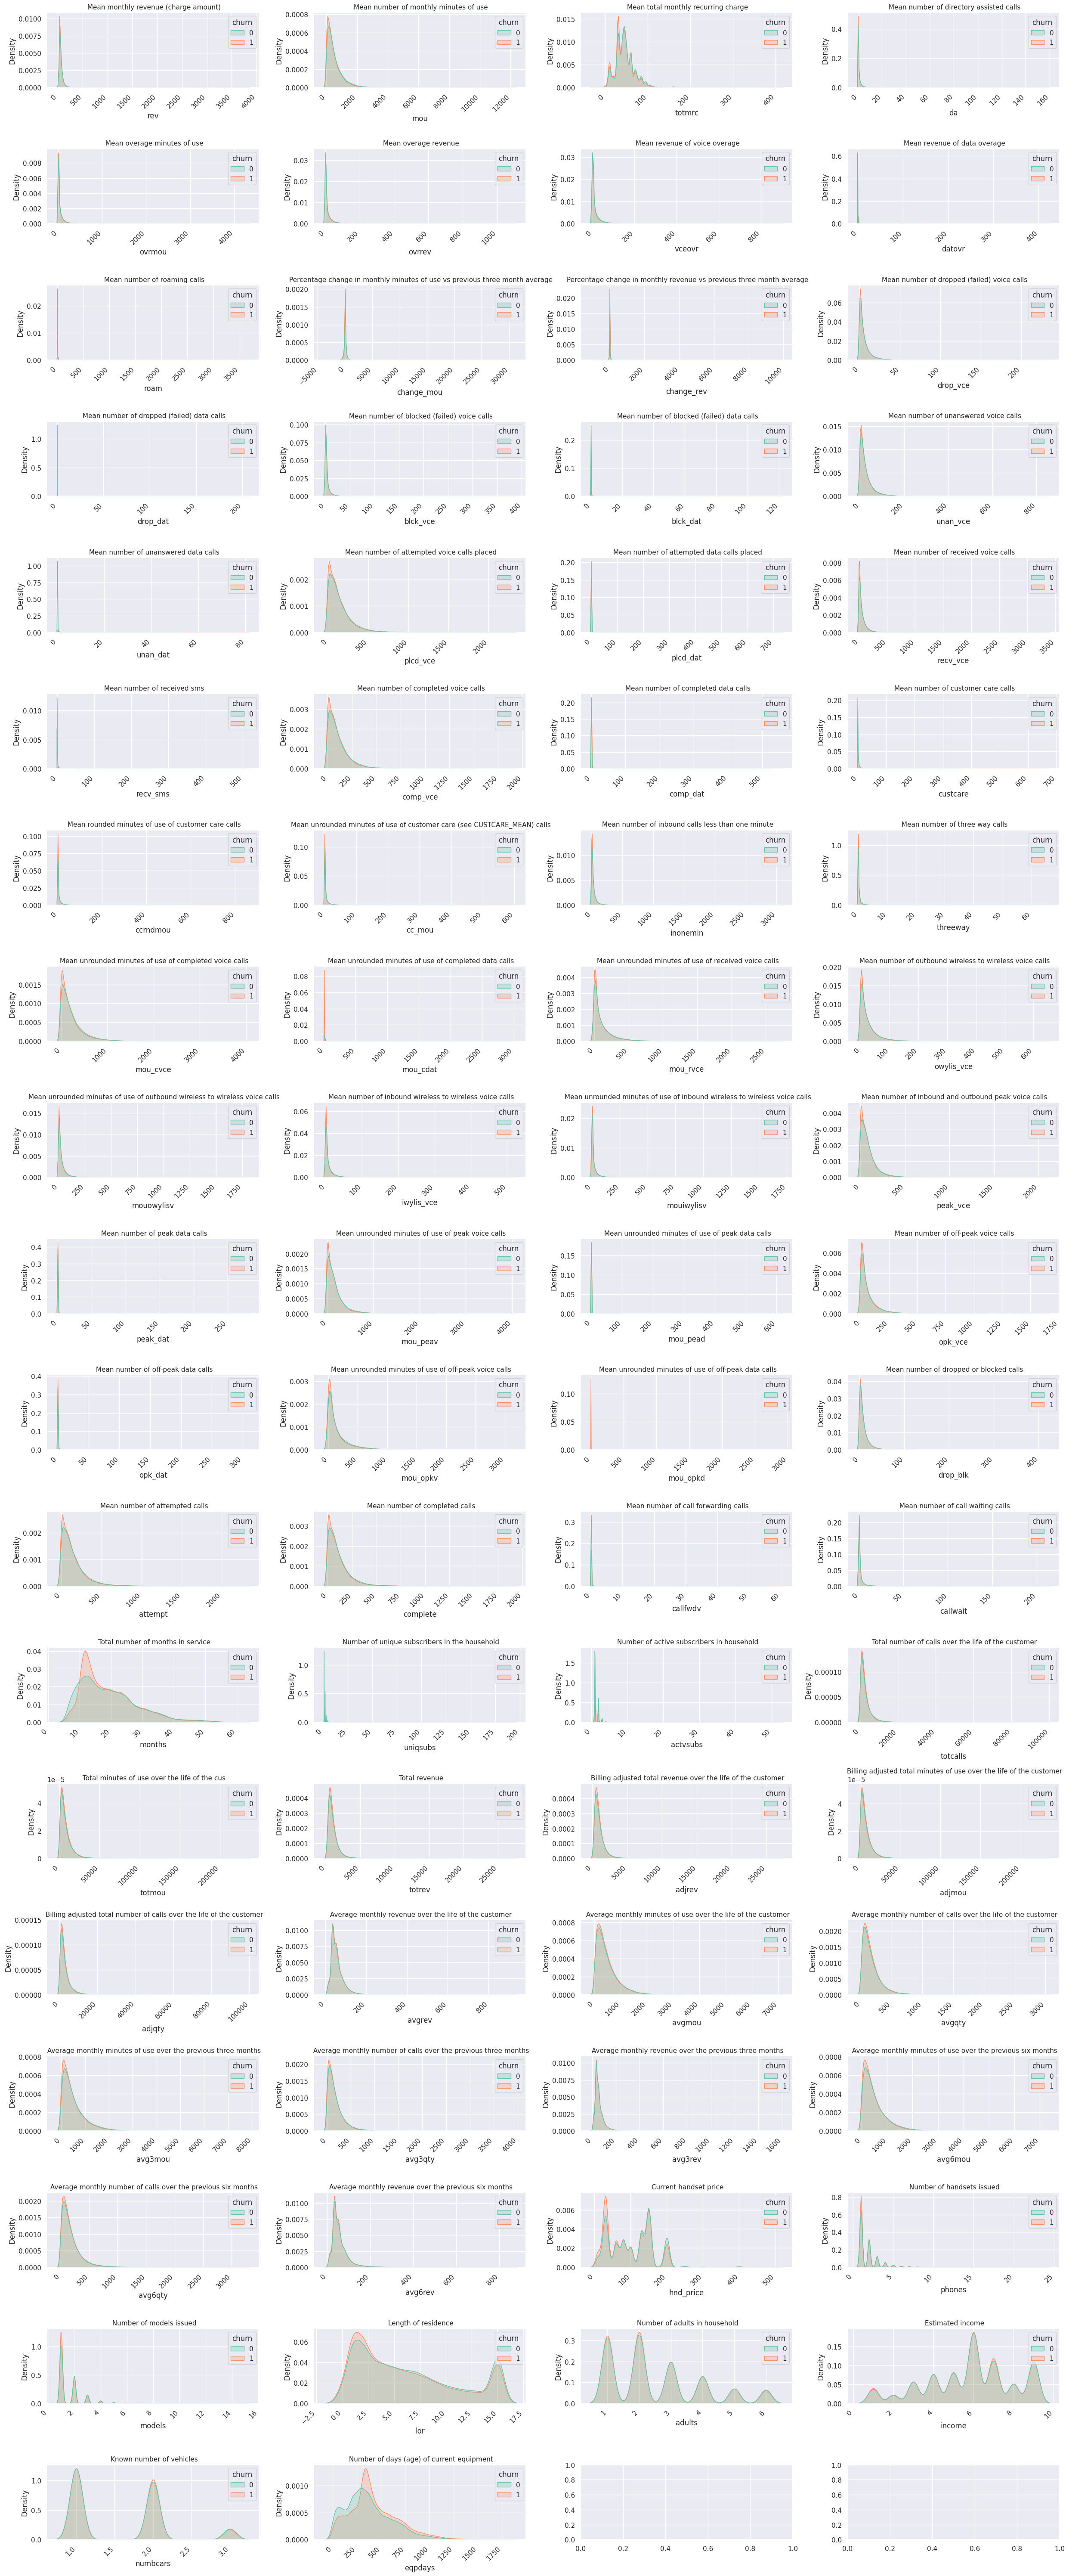

In [243]:
kdeplot_numerica_all_vs_target(df_telecom, lnum, 'churn', size_fig = (25 , 60))

In [244]:

def histplot_categorica_all(dataset, lista_categorica, target, size_fig = (30 , 30)):

    n_cols = 4
    n_rows = math.ceil(len(lista_categorica)/n_cols)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(size_fig))

    for i in lista_categorica:
        row_plot = lista_categorica.index(i) // n_cols
        col_plot = lista_categorica.index(i) % n_cols
        hist = sns.histplot(data=dataset,
                            x=i,
                            hue=target,
                            multiple='stack',
                            ax=axes[row_plot,col_plot],
                            palette='Set2')

        hist.set_xticklabels(hist.get_xticklabels(), rotation=45, ha='right', fontsize=11)

        plt.tight_layout()

        for bars in hist.containers:
            hist.bar_label(bars);

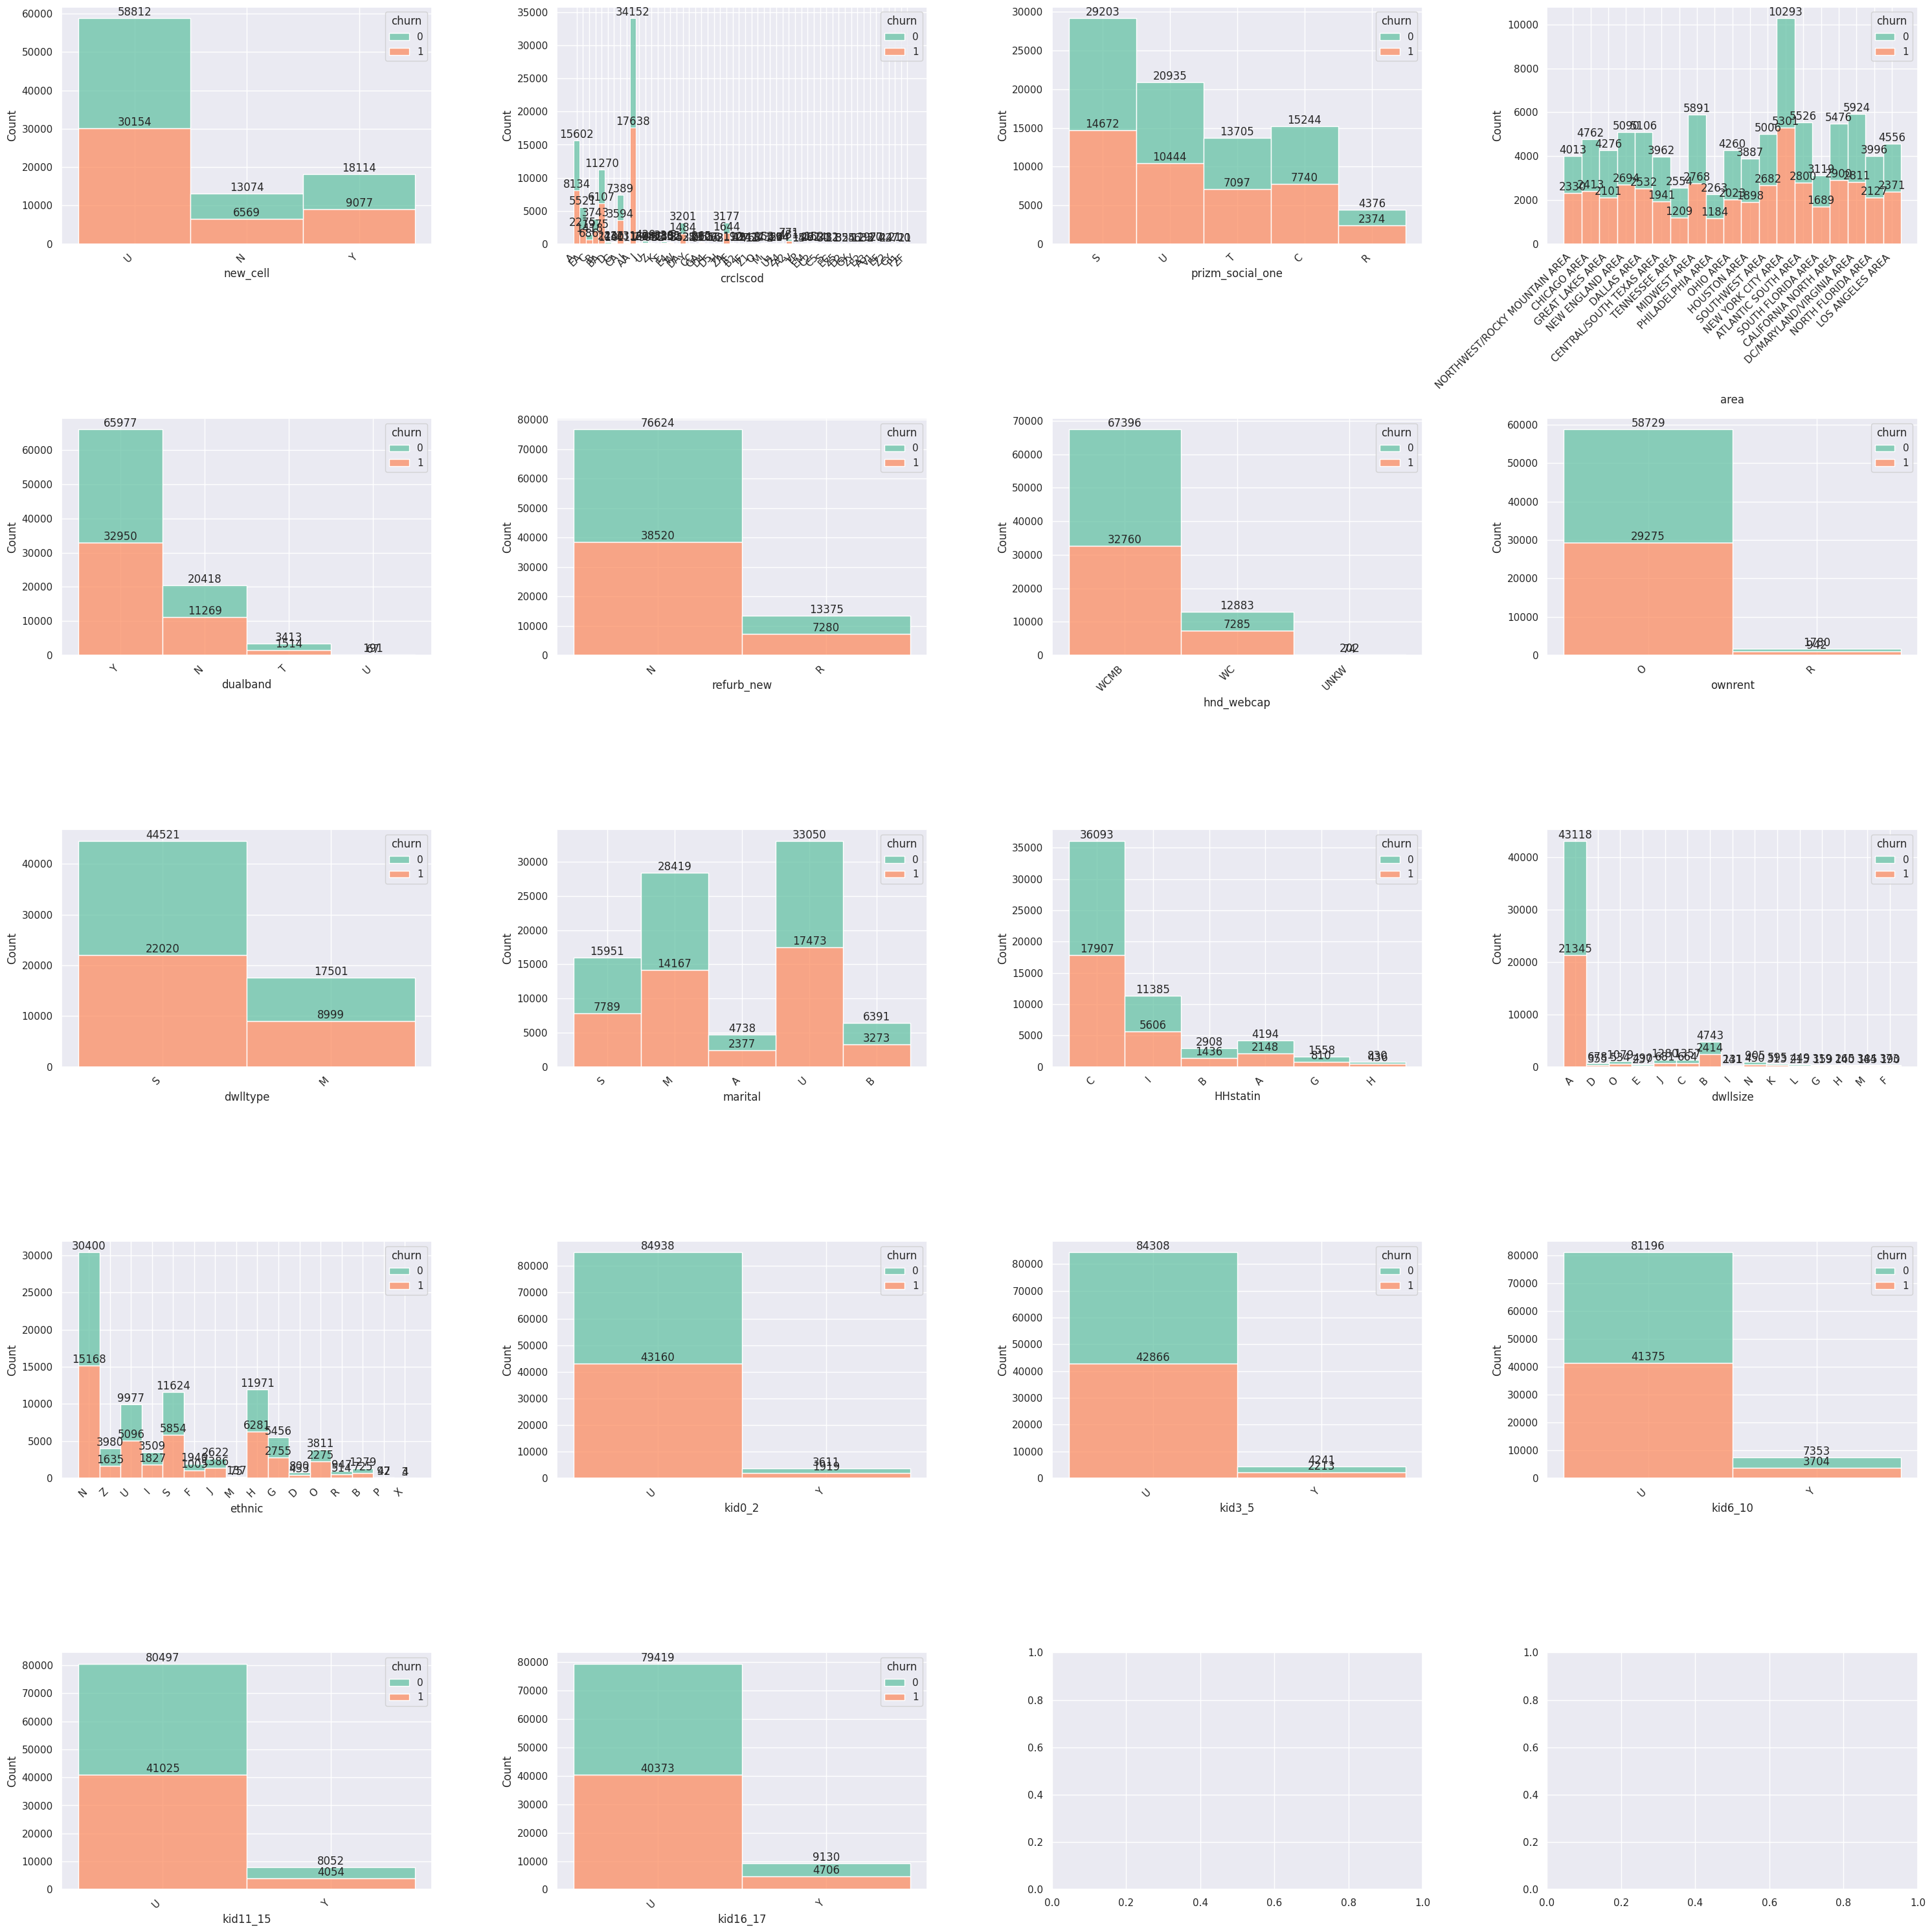

In [245]:
histplot_categorica_all(df_telecom, lcat, 'churn')

In [246]:
def countplot_boolean_all_vs_target(dataset, lista_boolean, target, size_fig = (30 , 30)):

    n_cols = 4
    n_rows = math.ceil(len(lista_boolean)/n_cols)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(size_fig))

    for i in lista_boolean:
        row_plot = lista_boolean.index(i) // n_cols
        col_plot = lista_boolean.index(i) % n_cols
        title_plot = df_desc[df_desc["Variable"]==i][" Description"].values[0]

        counts = sns.countplot(data=dataset,
                            x=i,
                            hue=target,
                            ax=axes[row_plot,col_plot],
                            palette='Set2')

        counts.set_title(title_plot, fontsize=11)
        counts.set_xticklabels(counts.get_xticklabels(), rotation=45, ha='right', fontsize=11)

        plt.tight_layout()

        for bars in counts.containers:
            counts.bar_label(bars);

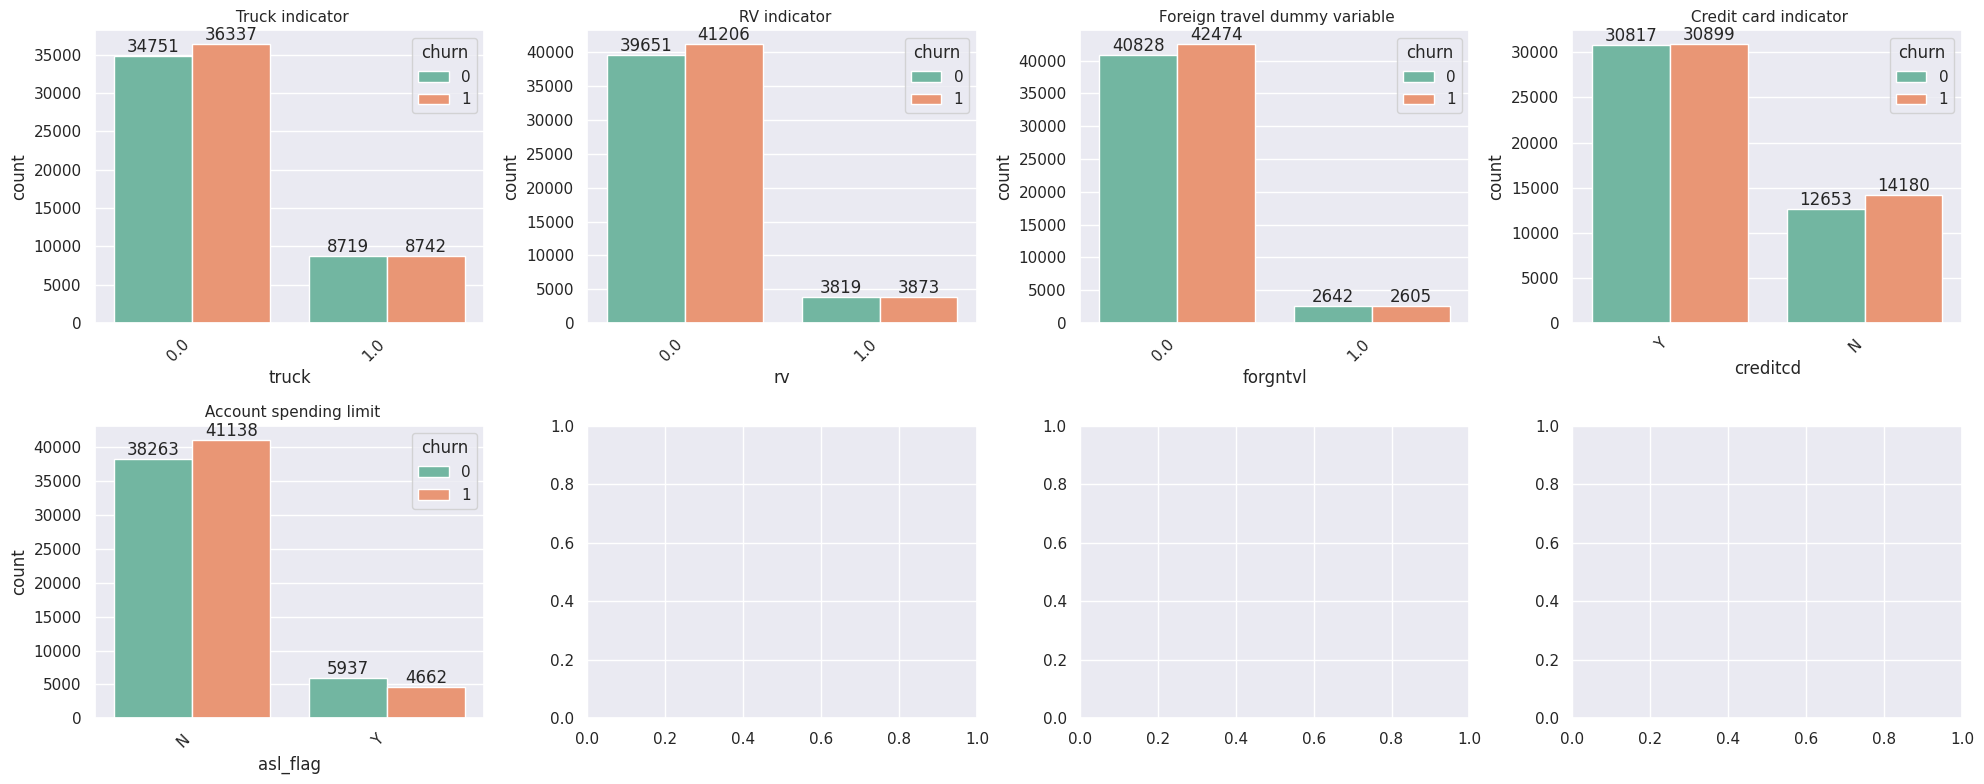

In [247]:
countplot_boolean_all_vs_target(df_telecom, lbool, 'churn', size_fig = (20 , 8))

# Data Cleaning

* Eliminar filas sin target informado.
* Eliminar filas duplicadas (si tenemos ID, solo puede haber 1 registro por ID)
* Eliminar filas/columnas vacías y columnas irrelevantes
* Corregir data types incorrectos
* Categoricos: Corregir literales incorrectos (acentos, erratas, etc)
* Fechas y textos: convertir a variables numericas (hour, day, month, year...) o categoricas (weekday_name...)

In [248]:
df_telecom2 = df_telecom.copy()

In [249]:
# no hay filas sin target informado

df_telecom2[df_telecom2['churn'].isnull()]

,rev,mou,totmrc,da,ovrmou,ovrrev,vceovr,datovr,roam,change_mou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID


In [250]:
# no hay filas enteras duplicadas

df_telecom2[df_telecom2.duplicated(keep=False)]

,rev,mou,totmrc,da,ovrmou,ovrrev,vceovr,datovr,roam,change_mou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID


In [251]:
# no hay IDs duplicados

if len(df_telecom2['Customer_ID'].unique()) - len(df_telecom2) == 0:
    print('No hay IDs duplicados')
else:
    print('Hya IDs duplicados, chequear')

No hay IDs duplicados


In [252]:
df_telecom2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 99 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rev               89866 non-null  float64
 1   mou               89866 non-null  float64
 2   totmrc            89866 non-null  float64
 3   da                89866 non-null  float64
 4   ovrmou            89866 non-null  float64
 5   ovrrev            89866 non-null  float64
 6   vceovr            89866 non-null  float64
 7   datovr            89866 non-null  float64
 8   roam              89866 non-null  float64
 9   change_mou        89405 non-null  float64
 10  change_rev        89405 non-null  float64
 11  drop_vce          90000 non-null  float64
 12  drop_dat          90000 non-null  float64
 13  blck_vce          90000 non-null  float64
 14  blck_dat          90000 non-null  float64
 15  unan_vce          90000 non-null  float64
 16  unan_dat          90000 non-null  float6

In [253]:
df_telecom2.select_dtypes(include='integer').columns

Index(['churn', 'months', 'uniqsubs', 'actvsubs', 'totcalls', 'adjqty',
       'avg3mou', 'avg3qty', 'avg3rev', 'Customer_ID'],
      dtype='object')

In [254]:
#chequeo de columnas integer

for i in df_telecom2.select_dtypes(include='integer').columns:
    print(df_telecom2[i].value_counts(dropna=False))
    print('')
    print('--------------')
    print('')

1    45800
0    44200
Name: churn, dtype: int64

--------------

11    7174
12    6025
13    5644
14    4545
19    3895
15    3832
23    3623
16    3598
10    3562
21    3560
17    3500
25    3060
18    3020
9     2843
20    2789
22    2507
7     2359
24    2328
8     2120
26    1905
27    1865
29    1531
28    1511
31    1469
30    1297
33    1155
32    1101
35    1031
34     913
37     778
6      749
36     706
38     502
39     448
41     343
40     287
43     278
47     242
42     236
45     234
44     215
49     202
46     193
48     192
50     146
51     137
53     109
52     107
54      59
55      34
56      23
57       6
58       6
59       4
60       1
61       1
Name: months, dtype: int64

--------------

1      55274
2      25205
3       5977
4       2340
5        757
6        275
7         98
8         36
9         19
10         7
11         5
12         3
13         2
18         1
196        1
Name: uniqsubs, dtype: int64

--------------

1     62914
2     22461
3      346

In [255]:
df_desc[df_desc['Variable'].isin(['avg3mou', 'avg3qty', 'avg3rev'])]

,Variable,Description,Tipo
64,avg3mou,Average monthly minutes of use over the previ...,int64
65,avg3qty,Average monthly number of calls over the prev...,int64
66,avg3rev,Average monthly revenue over the previous thr...,int64


In [256]:
# las siguientes columnas se deben cambiar a float ya que es extraño un promedio con tipo de dato int

columns_to_change_to_float = ['avg3mou', 'avg3qty', 'avg3rev']

for i in columns_to_change_to_float:

    df_telecom2[i] =  df_telecom2[i].astype('float')

print(f"Se ha cambiado el tipo de int a float de las siguientes columnas: {columns_to_change_to_float}")

Se ha cambiado el tipo de int a float de las siguientes columnas: ['avg3mou', 'avg3qty', 'avg3rev']


In [257]:
# check

df_telecom2.select_dtypes(include='integer').columns

Index(['churn', 'months', 'uniqsubs', 'actvsubs', 'totcalls', 'adjqty',
       'Customer_ID'],
      dtype='object')

In [258]:
df_telecom2.select_dtypes(include='float').columns

Index(['rev', 'mou', 'totmrc', 'da', 'ovrmou', 'ovrrev', 'vceovr', 'datovr',
       'roam', 'change_mou', 'change_rev', 'drop_vce', 'drop_dat', 'blck_vce',
       'blck_dat', 'unan_vce', 'unan_dat', 'plcd_vce', 'plcd_dat', 'recv_vce',
       'recv_sms', 'comp_vce', 'comp_dat', 'custcare', 'ccrndmou', 'cc_mou',
       'inonemin', 'threeway', 'mou_cvce', 'mou_cdat', 'mou_rvce',
       'owylis_vce', 'mouowylisv', 'iwylis_vce', 'mouiwylisv', 'peak_vce',
       'peak_dat', 'mou_peav', 'mou_pead', 'opk_vce', 'opk_dat', 'mou_opkv',
       'mou_opkd', 'drop_blk', 'attempt', 'complete', 'callfwdv', 'callwait',
       'totmou', 'totrev', 'adjrev', 'adjmou', 'avgrev', 'avgmou', 'avgqty',
       'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev',
       'hnd_price', 'phones', 'models', 'truck', 'rv', 'lor', 'adults',
       'income', 'numbcars', 'forgntvl', 'eqpdays'],
      dtype='object')

In [259]:
#chequeo de columnas float

for i in df_telecom2.select_dtypes(include='float').columns:
    print(df_telecom2[i].value_counts(dropna=False))
    print('')
    print('--------------')
    print('')

29.9900     2015
34.9900     1232
10.0000      832
30.0000      782
30.2600      718
            ... 
110.1900       1
216.2000       1
91.3450        1
92.1825        1
72.7450        1
Name: rev, Length: 35161, dtype: int64

--------------

0.000000       1493
NaN             134
0.250000        120
0.500000         84
0.750000         74
               ... 
2158.750000       1
3574.750000       1
1879.000000       1
2.666667          1
2022.250000       1
Name: mou, Length: 9181, dtype: int64

--------------

44.9900    9600
29.9900    8298
59.9900    7624
39.9900    7248
10.0000    5501
           ... 
48.6950       1
5.6475        1
25.8250       1
89.7775       1
34.9650       1
Name: totmrc, Length: 7677, dtype: int64

--------------

0.0000     43789
0.2475     11924
0.4950      6978
0.7425      4794
0.9900      3549
           ...  
65.8350        1
36.1350        1
31.4325        1
40.5900        1
34.6500        1
Name: da, Length: 164, dtype: int64

--------------

0.00    

In [260]:
df_desc[df_desc['Variable'].isin(['phones', 'models', 'truck', 'rv', 'lor', 'adults', 'income', 'numbcars', 'forgntvl', 'eqpdays'])]

,Variable,Description,Tipo
75,phones,Number of handsets issued,float64
76,models,Number of models issued,float64
78,truck,Truck indicator,float64
79,rv,RV indicator,float64
81,lor,Length of residence,float64
84,adults,Number of adults in household,float64
85,income,Estimated income,float64
86,numbcars,Known number of vehicles,float64
89,forgntvl,Foreign travel dummy variable,float64
97,eqpdays,Number of days (age) of current equipment,float64


In [261]:
# las siguientes columnas se deben cambiar a integer

columns_to_change_to_int = ['phones', 'models', 'truck', 'rv', 'lor', 'adults', 'income', 'numbcars', 'forgntvl', 'eqpdays']

for i in columns_to_change_to_int:

    df_telecom2[i] =  df_telecom2[i].astype('Int64')

print(f"Se ha cambiado el tipo de float a int de las siguientes columnas: {columns_to_change_to_int}")

Se ha cambiado el tipo de float a int de las siguientes columnas: ['phones', 'models', 'truck', 'rv', 'lor', 'adults', 'income', 'numbcars', 'forgntvl', 'eqpdays']


In [262]:
# check

df_telecom2.select_dtypes(include='float').columns

Index(['rev', 'mou', 'totmrc', 'da', 'ovrmou', 'ovrrev', 'vceovr', 'datovr',
       'roam', 'change_mou', 'change_rev', 'drop_vce', 'drop_dat', 'blck_vce',
       'blck_dat', 'unan_vce', 'unan_dat', 'plcd_vce', 'plcd_dat', 'recv_vce',
       'recv_sms', 'comp_vce', 'comp_dat', 'custcare', 'ccrndmou', 'cc_mou',
       'inonemin', 'threeway', 'mou_cvce', 'mou_cdat', 'mou_rvce',
       'owylis_vce', 'mouowylisv', 'iwylis_vce', 'mouiwylisv', 'peak_vce',
       'peak_dat', 'mou_peav', 'mou_pead', 'opk_vce', 'opk_dat', 'mou_opkv',
       'mou_opkd', 'drop_blk', 'attempt', 'complete', 'callfwdv', 'callwait',
       'totmou', 'totrev', 'adjrev', 'adjmou', 'avgrev', 'avgmou', 'avgqty',
       'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev',
       'hnd_price'],
      dtype='object')

In [263]:
# chequeo de columnas boolean

df_telecom2.select_dtypes(include='bool').columns

Index([], dtype='object')

In [264]:
# chequeo de columnas object/string

df_telecom2.select_dtypes(include='object').columns

Index(['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area',
       'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype',
       'marital', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5',
       'kid6_10', 'kid11_15', 'kid16_17', 'creditcd'],
      dtype='object')

In [265]:
for i in df_telecom2.select_dtypes(include='object').columns:
    print(df_telecom2[i].value_counts(dropna=False))
    print('')
    print('--------------')
    print('')

U    58812
Y    18114
N    13074
Name: new_cell, dtype: int64

--------------

AA    34152
A     15602
BA    11270
CA     7389
EA     5521
B      3743
DA     3201
ZA     3177
C      1418
A2      771
U       429
E       330
E4      305
GA      265
D       244
G       236
I       231
JF      192
Z       187
J       169
M       153
C2      152
D4      107
Z4       94
K        93
W        84
V1       70
U1       56
EM       46
B2       42
Y        38
EC       32
O        24
CY       21
E2       19
CC       19
D5       16
C5       14
IF       14
ZY       12
Z1       11
Z5        8
H         8
TP        5
D2        5
GY        5
L         4
EF        4
Z2        4
A3        3
P1        2
S         1
V         1
ZF        1
Name: crclscod, dtype: int64

--------------

N    79401
Y    10599
Name: asl_flag, dtype: int64

--------------

S      29203
U      20935
C      15244
T      13705
NaN     6537
R       4376
Name: prizm_social_one, dtype: int64

--------------

NEW YORK CITY AREA         

In [266]:
df_desc[df_desc['Variable'].isin(['asl_flag', 'creditcd'])]

,Variable,Description,Tipo
54,asl_flag,Account spending limit,object
96,creditcd,Credit card indicator,object


In [267]:
for i in ['asl_flag', 'creditcd']:
    print(df_telecom2[i].value_counts(dropna=False))
    print('')
    print('--------------')
    print('')

N    79401
Y    10599
Name: asl_flag, dtype: int64

--------------

Y      61716
N      26833
NaN     1451
Name: creditcd, dtype: int64

--------------



In [268]:
# las siguientes columnas se deben cambiar a integer y tambien sus valores deben ser reemplazados por 0 y 1

Lista_limpieza_valores_boolean = ['asl_flag', 'creditcd']

def limpieza_valores_boolean(dataset, lista_columnas):

    for i in lista_columnas:

        dataset[i] = np.where(dataset[i] == 'N', 0, dataset[i])
        dataset[i] = np.where(dataset[i] == 'Y', 1, dataset[i])
        dataset[i] = dataset[i].astype('Int64')

limpieza_valores_boolean(df_telecom2, Lista_limpieza_valores_boolean)

for i in ['asl_flag', 'creditcd']:
    print(df_telecom2[i].value_counts(dropna=False))
    print('')
    print('--------------')
    print('')

print('')

print(df_telecom2[['asl_flag', 'creditcd']].info())

0       79401
1       10599
<NA>        0
Name: asl_flag, dtype: Int64

--------------

1       61716
0       26833
<NA>     1451
Name: creditcd, dtype: Int64

--------------


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   asl_flag  90000 non-null  Int64
 1   creditcd  88549 non-null  Int64
dtypes: Int64(2)
memory usage: 1.5 MB
None


In [269]:
# chequeo de que todas las columnas fueron analizadas

columnas_analizadas = len(df_telecom2.select_dtypes(include='integer').columns) + \
                      len(df_telecom2.select_dtypes(include='float').columns) + \
                      len(df_telecom2.select_dtypes(include='bool').columns) + \
                      len(df_telecom2.select_dtypes(include='object').columns) + \
                      len(df_telecom2.select_dtypes(include='datetime').columns)

if (columnas_analizadas - len(df_telecom2.columns)) == 0:
    print('Todas las columnas analizadas')
else:
    print('Aún quedan columnas por analizar, chequear')

Todas las columnas analizadas


In [270]:
tipos = df_telecom2.dtypes

df_desc_clean = df_desc.copy()

df_desc_clean['Tipo'] = tipos.values

In [271]:
df_desc['Variable'].unique() == df_desc_clean['Variable'].unique()

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

In [272]:
df_desc[df_desc['Variable'] == 'creditcd']

,Variable,Description,Tipo
96,creditcd,Credit card indicator,object


In [273]:
df_desc_clean[df_desc_clean['Variable'] == 'creditcd']

,Variable,Description,Tipo
96,creditcd,Credit card indicator,Int64


In [274]:
df_telecom2[lbool].dtypes.unique()

array([Int64Dtype()], dtype=object)

In [275]:
df_telecom2[lcat].dtypes.unique()

array([dtype('O')], dtype=object)

In [276]:
df_telecom2[lnum].dtypes.unique()

array([dtype('float64'), dtype('int64'), Int64Dtype()], dtype=object)

In [277]:
df_telecom2[lbool].describe()

,truck,rv,forgntvl,creditcd,asl_flag
count,88549.0,88549.0,88549.0,88549.0,90000.0
mean,0.19719,0.086867,0.059255,0.69697,0.117767
std,0.397879,0.281642,0.236103,0.459571,0.322333
min,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,1.0,0.0
75%,0.0,0.0,0.0,1.0,0.0
max,1.0,1.0,1.0,1.0,1.0


In [278]:
df_describe = df_telecom2[lnum].describe().loc[['min']].T

list_columns_min_less_than_zero = df_describe[df_describe['min']<0].index

df_telecom2[list_columns_min_less_than_zero].describe()

,rev,totmrc,change_mou,change_rev,avg6rev,eqpdays
count,89866.000000,89866.000000,89405.000000,89405.000000,88593.000000,89999.0
mean,58.312895,45.880669,-13.786987,-1.074666,58.266691,402.419438
std,46.084103,23.370435,271.624916,50.565668,40.483529,252.82166
min,-5.862500,-26.915000,-3875.000000,-1107.740000,-2.000000,-5.0
25%,33.027500,30.000000,-85.750000,-7.212500,34.000000,227.0
50%,47.667500,44.990000,-6.500000,-0.315000,49.000000,359.0
75%,70.193750,59.990000,61.250000,1.537500,70.000000,547.0
max,3843.262500,409.990000,31219.250000,9963.657500,866.000000,1812.0


In [279]:
df_desc_clean[df_desc_clean['Variable'].isin(list_columns_min_less_than_zero)]

,Variable,Description,Tipo
0,rev,Mean monthly revenue (charge amount),float64
2,totmrc,Mean total monthly recurring charge,float64
9,change_mou,Percentage change in monthly minutes of use v...,float64
10,change_rev,Percentage change in monthly revenue vs previ...,float64
69,avg6rev,Average monthly revenue over the previous six...,float64
97,eqpdays,Number of days (age) of current equipment,Int64


-3    32
-1    27
-2    26
-4    12
-5     5
Name: eqpdays, dtype: Int64

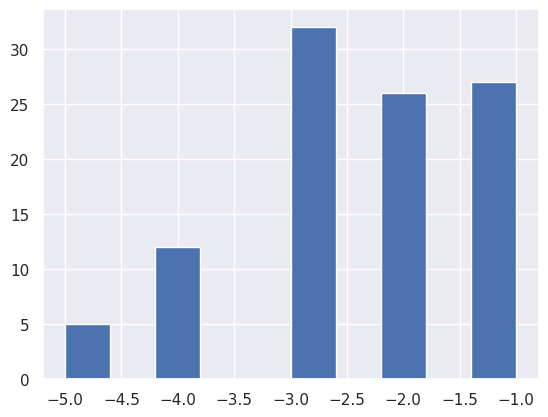

In [280]:
# de las columnas anteriores, solo eqpdays no tendría sentido admitir valores negativos
# ya que no puede haber un equipo con antiguedad negativa

df_eqp_days_less_than_zero = df_telecom2[df_telecom2['eqpdays']<0]

df_eqp_days_less_than_zero['eqpdays'].hist();

df_eqp_days_less_than_zero['eqpdays'].value_counts()

In [281]:
df_telecom2['eqpdays'].mode()[0]

310

In [282]:
moda = df_telecom2['eqpdays'].mode()[0]

def imputar_negativos_eqp_days(series):
    return series.apply(lambda x: moda if pd.notnull(x) and x < 0  else x)

In [283]:
negative_eqp_days_function = FunctionTransformer(func = imputar_negativos_eqp_days)

In [284]:
negative_eqp_days_function

FunctionTransformer(func=<function imputar_negativos_eqp_days at 0x788e3550e320>)

In [285]:
df_telecom2['eqpdays'] = negative_eqp_days_function.fit_transform(df_telecom2['eqpdays'])

print("Se han reemplazado los valores negativos por la moda para las siguientes columnas: 'eqpdays'")

Se han reemplazado los valores negativos por la moda para las siguientes columnas: 'eqpdays'


In [286]:
len(df_telecom2[df_telecom2['eqpdays']<0])

0

In [287]:
df_telecom2['eqpdays'] = df_telecom2['eqpdays'].astype('Int64')

print("Se ha cambiado el tipo de dato a int para las siguientes columnas: 'eqpdays'")

Se ha cambiado el tipo de dato a int para las siguientes columnas: 'eqpdays'


In [288]:
df_telecom2['eqpdays'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 90000 entries, 0 to 89999
Series name: eqpdays
Non-Null Count  Dtype
--------------  -----
89999 non-null  Int64
dtypes: Int64(1)
memory usage: 791.1 KB


In [289]:
df_telecom2['eqpdays'].describe()

count       89999.0
mean     402.773531
std      252.472935
min             0.0
25%           227.0
50%           359.0
75%           547.0
max          1812.0
Name: eqpdays, dtype: Float64

# Imputación de nulos

* MODELOS DE ARBOLES: Imputar valor outlier.
* MODELOS LINEALES: imputar media, mediana o moda.
* Si vamos a practicar un Torneo de Modelos, preferible imputar valor outlier.

In [290]:
df_telecom3 = df_telecom2.copy()

In [291]:
lista_imputar_categorico = list(df_telecom3.select_dtypes(include='O').columns)

lista_imputar_categorico

['new_cell',
 'crclscod',
 'prizm_social_one',
 'area',
 'dualband',
 'refurb_new',
 'hnd_webcap',
 'ownrent',
 'dwlltype',
 'marital',
 'HHstatin',
 'dwllsize',
 'ethnic',
 'kid0_2',
 'kid3_5',
 'kid6_10',
 'kid11_15',
 'kid16_17']

In [292]:
lista_imputar_numerico = list(df_telecom3.select_dtypes(include='number').columns)

lista_imputar_numerico

['rev',
 'mou',
 'totmrc',
 'da',
 'ovrmou',
 'ovrrev',
 'vceovr',
 'datovr',
 'roam',
 'change_mou',
 'change_rev',
 'drop_vce',
 'drop_dat',
 'blck_vce',
 'blck_dat',
 'unan_vce',
 'unan_dat',
 'plcd_vce',
 'plcd_dat',
 'recv_vce',
 'recv_sms',
 'comp_vce',
 'comp_dat',
 'custcare',
 'ccrndmou',
 'cc_mou',
 'inonemin',
 'threeway',
 'mou_cvce',
 'mou_cdat',
 'mou_rvce',
 'owylis_vce',
 'mouowylisv',
 'iwylis_vce',
 'mouiwylisv',
 'peak_vce',
 'peak_dat',
 'mou_peav',
 'mou_pead',
 'opk_vce',
 'opk_dat',
 'mou_opkv',
 'mou_opkd',
 'drop_blk',
 'attempt',
 'complete',
 'callfwdv',
 'callwait',
 'churn',
 'months',
 'uniqsubs',
 'actvsubs',
 'asl_flag',
 'totcalls',
 'totmou',
 'totrev',
 'adjrev',
 'adjmou',
 'adjqty',
 'avgrev',
 'avgmou',
 'avgqty',
 'avg3mou',
 'avg3qty',
 'avg3rev',
 'avg6mou',
 'avg6qty',
 'avg6rev',
 'hnd_price',
 'phones',
 'models',
 'truck',
 'rv',
 'lor',
 'adults',
 'income',
 'numbcars',
 'forgntvl',
 'creditcd',
 'eqpdays',
 'Customer_ID']

In [293]:
lista_imputar_booleano = []

for i in lbool:
    lista_imputar_numerico.remove(i)
    lista_imputar_booleano.append(i)

lista_imputar_booleano

['truck', 'rv', 'forgntvl', 'creditcd', 'asl_flag']

In [294]:
if len(df_telecom3.columns) - (len(lista_imputar_categorico) + len(lista_imputar_numerico) + len(lista_imputar_booleano)) == 0:
    print('Todas las columnas asignadas para imputar')
else:
    print('Check, columnas sin imputación asginada')

Todas las columnas asignadas para imputar


In [295]:
df_telecom3.set_index('Customer_ID', inplace=True)

In [296]:
lista_imputar_numerico.remove('Customer_ID')
lista_imputar_numerico.remove('churn')

if len(df_telecom3.columns) - (len(lista_imputar_categorico) + len(lista_imputar_numerico) + len(lista_imputar_booleano)) - 1 == 0:
    print('Todas las columnas asignadas para imputar')
else:
    print('Check, columnas sin imputación asginada')

Todas las columnas asignadas para imputar


In [297]:
df_telecom3.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 90000 entries, 1000001 to 1090000
Data columns (total 98 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rev               89866 non-null  float64
 1   mou               89866 non-null  float64
 2   totmrc            89866 non-null  float64
 3   da                89866 non-null  float64
 4   ovrmou            89866 non-null  float64
 5   ovrrev            89866 non-null  float64
 6   vceovr            89866 non-null  float64
 7   datovr            89866 non-null  float64
 8   roam              89866 non-null  float64
 9   change_mou        89405 non-null  float64
 10  change_rev        89405 non-null  float64
 11  drop_vce          90000 non-null  float64
 12  drop_dat          90000 non-null  float64
 13  blck_vce          90000 non-null  float64
 14  blck_dat          90000 non-null  float64
 15  unan_vce          90000 non-null  float64
 16  unan_dat          90000 non-null

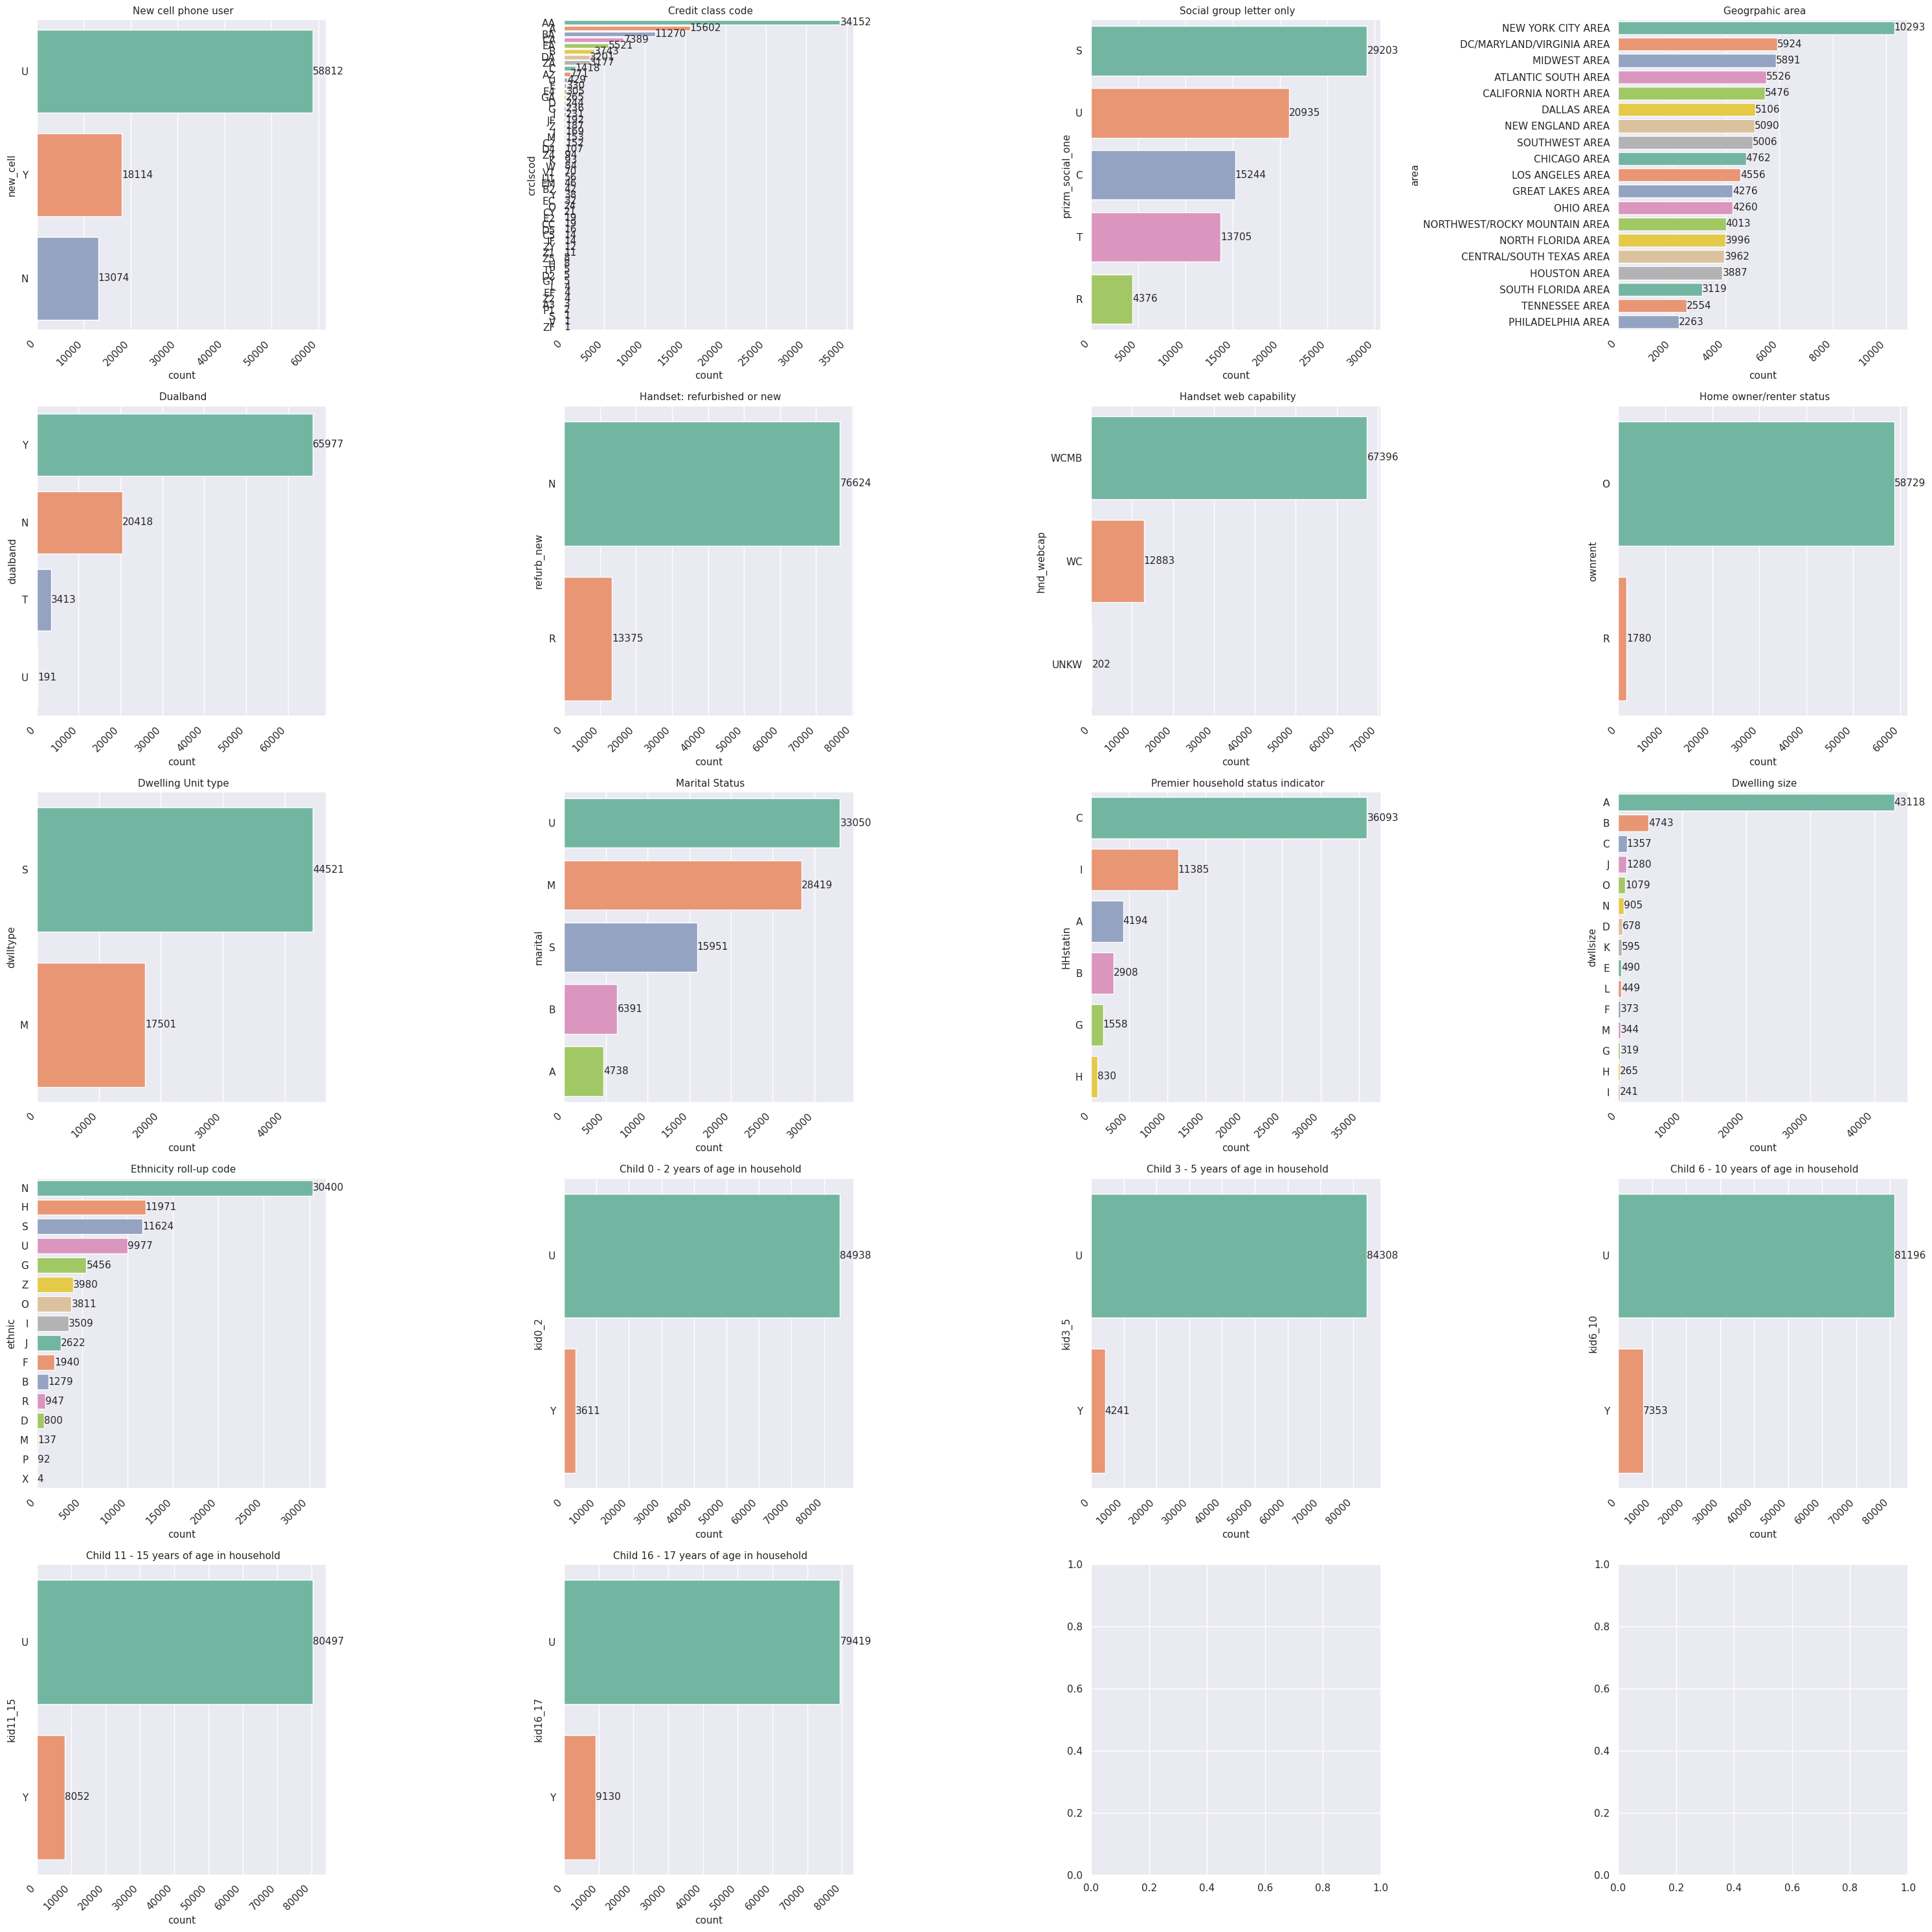

In [298]:
countplot_bool_all(df_telecom3, lista_imputar_categorico)

In [299]:
# algunos categoricos tienen etiquetas distintas para los nulos por lo que tenemos que imputar de manera acorde

lista_imputar_categorico_UNKW = ['hnd_webcap']
lista_imputar_categorico_UNKWOWN = ['area']
lista_imputar_categorico_U = [i for i in lista_imputar_categorico if i not in lista_imputar_categorico_UNKW and i not in lista_imputar_categorico_UNKWOWN]

len(lista_imputar_categorico) - (len(lista_imputar_categorico_UNKW) + len(lista_imputar_categorico_UNKWOWN) + len(lista_imputar_categorico_U))

0

In [300]:
impute_pipe = ColumnTransformer(
        transformers = [
                    ("numeric_impute", SimpleImputer(strategy='constant', fill_value=-999), lista_imputar_numerico),
                    ("categorical_impute_1", SimpleImputer(strategy='constant', fill_value='U'), lista_imputar_categorico_U),
                    ("categorical_impute_2", SimpleImputer(strategy='constant', fill_value='UNKW'), lista_imputar_categorico_UNKW),
                    ("categorical_impute_3", SimpleImputer(strategy='constant', fill_value='UNKWOWN'), lista_imputar_categorico_UNKWOWN),
                    ("boolean_impute", SimpleImputer(strategy='constant', fill_value=-1), lista_imputar_booleano)
                ],
            remainder='passthrough'
)

df_telecom3 = impute_pipe.fit_transform(df_telecom3)

In [301]:
impute_pipe

ColumnTransformer(remainder='passthrough',
                  transformers=[('numeric_impute',
                                 SimpleImputer(fill_value=-999,
                                               strategy='constant'),
                                 ['rev', 'mou', 'totmrc', 'da', 'ovrmou',
                                  'ovrrev', 'vceovr', 'datovr', 'roam',
                                  'change_mou', 'change_rev', 'drop_vce',
                                  'drop_dat', 'blck_vce', 'blck_dat',
                                  'unan_vce', 'unan_dat', 'plcd_vce',
                                  'plcd_dat', 'recv_vce', 'recv_sms',
                                  'comp_vce', 'comp_da...
                                  'ethnic', 'kid0_2', 'kid3_5', 'kid6_10',
                                  'kid11_15', 'kid16_17']),
                                ('categorical_impute_2',
                                 SimpleImputer(fill_value='UNKW',
                                               strategy='constant'),
                                 ['hnd_webcap']),
                                ('categorical_impute_3',
                                 SimpleImputer(fill_value='UNKWOWN',
                                               strategy='constant'),
                                 ['area']),
                                ('boolean_impute',
                                 SimpleImputer(fill_value=-1,
                                               strategy='constant'),
                                 ['truck', 'rv', 'forgntvl', 'creditcd',
                                  'asl_flag'])])

In [302]:
len(df_telecom3[df_telecom3['numeric_impute__eqpdays']<0])

1

In [303]:
# guardamos un diccionario con todas las imputaciones

numeric_impute =  dict(zip(impute_pipe.transformers_[0][2] , impute_pipe.transformers_[0][1].statistics_))
categorical_impute_1 =  dict(zip(impute_pipe.transformers_[1][2] , impute_pipe.transformers_[1][1].statistics_))
categorical_impute_2 =  dict(zip(impute_pipe.transformers_[2][2] , impute_pipe.transformers_[2][1].statistics_))
categorical_impute_3 =  dict(zip(impute_pipe.transformers_[3][2] , impute_pipe.transformers_[3][1].statistics_))
boolean_impute =  dict(zip(impute_pipe.transformers_[4][2] , impute_pipe.transformers_[4][1].statistics_))

print('Se han imputado los siguientes valores en las siguientes columnas para los nulos:')
print('')
print('numeric_impute', numeric_impute)
print('categorical_impute_1', categorical_impute_1)
print('categorical_impute_2', categorical_impute_2)
print('categorical_impute_3', categorical_impute_3)
print('boolean_impute', boolean_impute)

Se han imputado los siguientes valores en las siguientes columnas para los nulos:

numeric_impute {'rev': -999.0, 'mou': -999.0, 'totmrc': -999.0, 'da': -999.0, 'ovrmou': -999.0, 'ovrrev': -999.0, 'vceovr': -999.0, 'datovr': -999.0, 'roam': -999.0, 'change_mou': -999.0, 'change_rev': -999.0, 'drop_vce': -999.0, 'drop_dat': -999.0, 'blck_vce': -999.0, 'blck_dat': -999.0, 'unan_vce': -999.0, 'unan_dat': -999.0, 'plcd_vce': -999.0, 'plcd_dat': -999.0, 'recv_vce': -999.0, 'recv_sms': -999.0, 'comp_vce': -999.0, 'comp_dat': -999.0, 'custcare': -999.0, 'ccrndmou': -999.0, 'cc_mou': -999.0, 'inonemin': -999.0, 'threeway': -999.0, 'mou_cvce': -999.0, 'mou_cdat': -999.0, 'mou_rvce': -999.0, 'owylis_vce': -999.0, 'mouowylisv': -999.0, 'iwylis_vce': -999.0, 'mouiwylisv': -999.0, 'peak_vce': -999.0, 'peak_dat': -999.0, 'mou_peav': -999.0, 'mou_pead': -999.0, 'opk_vce': -999.0, 'opk_dat': -999.0, 'mou_opkv': -999.0, 'mou_opkd': -999.0, 'drop_blk': -999.0, 'attempt': -999.0, 'complete': -999.0, 'cal

In [304]:
df_telecom3.isnull().sum().sum()

0

# Encoding categóricos

* Si tienen sentido ordinal, es decir, se pueden ordenar, encodear con una escala numerica. Ejemplo: {"Bajo":1, "Medio":2, "Alto":3}.
* Si tienen unicamente 2 clases, indicador booleano
* One Hot Encoding en resto de categoricos

In [305]:
#actualizamos nuestra lista de variables

lnum_impute = ['numeric_impute__' + item for item in lnum]

lcat_impute_U = ['categorical_impute_1__' + item for item in lista_imputar_categorico_U]
lcat_impute_UNKW = ['categorical_impute_2__' + item for item in lista_imputar_categorico_UNKW]
lcat_impute_UNKWOWN = ['categorical_impute_3__' + item for item in lista_imputar_categorico_UNKWOWN]

lbool_impute = ['boolean_impute__' + item for item in lbool]

In [306]:
#actualizamos nuestra lista de variables

lista_imputar_numerico_impute = ['numeric_impute__' + item for item in lista_imputar_numerico]

lista_imputar_categorico_impute_U = ['categorical_impute_1__' + item for item in lista_imputar_categorico_U]
lista_imputar_categorico_impute_UNKW = ['categorical_impute_2__' + item for item in lista_imputar_categorico_UNKW]
lista_imputar_categorico_impute_UNKWOWN = ['categorical_impute_3__' + item for item in lista_imputar_categorico_UNKWOWN]

lista_imputar_booleano_impute = ['boolean_impute__' + item for item in lista_imputar_booleano]

In [307]:
df_telecom4 = df_telecom3.copy()

In [308]:
lnum_impute.index('numeric_impute__eqpdays')


73

In [309]:
lnum[73]

'eqpdays'

In [310]:
lnum.index('eqpdays')

73

In [311]:
df_desc_clean_impute = df_desc_clean.copy()

In [312]:
list_to_replace = lista_imputar_numerico_impute
list_to_search = lista_imputar_numerico

for i in list_to_replace:

    indice_final = list_to_replace.index(i)
    valor_final = list_to_replace[indice_final]

    valor_buscar = list_to_search[indice_final]

    df_desc_clean_impute['Variable'] = np.where(df_desc_clean_impute['Variable'] == valor_buscar, valor_final , df_desc_clean_impute['Variable'])

In [313]:
list_to_replace = lista_imputar_categorico_impute_U
list_to_search = lista_imputar_categorico_U

for i in list_to_replace:

    indice_final = list_to_replace.index(i)
    valor_final = list_to_replace[indice_final]

    valor_buscar = list_to_search[indice_final]

    df_desc_clean_impute['Variable'] = np.where(df_desc_clean_impute['Variable'] == valor_buscar, valor_final , df_desc_clean_impute['Variable'])

In [314]:
list_to_replace = lista_imputar_categorico_impute_UNKW
list_to_search = lista_imputar_categorico_UNKW

for i in list_to_replace:

    indice_final = list_to_replace.index(i)
    valor_final = list_to_replace[indice_final]

    valor_buscar = list_to_search[indice_final]

    df_desc_clean_impute['Variable'] = np.where(df_desc_clean_impute['Variable'] == valor_buscar, valor_final , df_desc_clean_impute['Variable'])

In [315]:
list_to_replace = lista_imputar_categorico_impute_UNKWOWN
list_to_search = lista_imputar_categorico_UNKWOWN

for i in list_to_replace:

    indice_final = list_to_replace.index(i)
    valor_final = list_to_replace[indice_final]

    valor_buscar = list_to_search[indice_final]

    df_desc_clean_impute['Variable'] = np.where(df_desc_clean_impute['Variable'] == valor_buscar, valor_final , df_desc_clean_impute['Variable'])

In [316]:
list_to_replace = lista_imputar_booleano_impute
list_to_search = lista_imputar_booleano

for i in list_to_replace:

    indice_final = list_to_replace.index(i)
    valor_final = list_to_replace[indice_final]

    valor_buscar = list_to_search[indice_final]

    df_desc_clean_impute['Variable'] = np.where(df_desc_clean_impute['Variable'] == valor_buscar, valor_final , df_desc_clean_impute['Variable'])

In [317]:
df_desc_clean_impute[df_desc_clean_impute['Variable'] == 'Customer_ID']

,Variable,Description,Tipo
98,Customer_ID,Customer ID (Primary key),int64


In [318]:
df_desc_clean_impute['Variable'] = np.where(df_desc_clean_impute['Variable'] == 'churn', 'remainder__churn', df_desc_clean_impute['Variable'])
df_desc_clean_impute.drop(index = df_desc_clean_impute[df_desc_clean_impute['Variable'] == 'Customer_ID'].index, inplace=True)


In [319]:
df_desc_clean_impute['Variable'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 98 entries, 0 to 97
Series name: Variable
Non-Null Count  Dtype 
--------------  ----- 
98 non-null     object
dtypes: object(1)
memory usage: 912.0+ bytes


In [320]:
df_telecom4.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 90000 entries, 1000001 to 1090000
Data columns (total 98 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   numeric_impute__rev                     90000 non-null  float64
 1   numeric_impute__mou                     90000 non-null  float64
 2   numeric_impute__totmrc                  90000 non-null  float64
 3   numeric_impute__da                      90000 non-null  float64
 4   numeric_impute__ovrmou                  90000 non-null  float64
 5   numeric_impute__ovrrev                  90000 non-null  float64
 6   numeric_impute__vceovr                  90000 non-null  float64
 7   numeric_impute__datovr                  90000 non-null  float64
 8   numeric_impute__roam                    90000 non-null  float64
 9   numeric_impute__change_mou              90000 non-null  float64
 10  numeric_impute__change_rev              90000 non-

In [321]:
df_desc_clean_impute['Variable'].unique()

array(['numeric_impute__rev', 'numeric_impute__mou',
       'numeric_impute__totmrc', 'numeric_impute__da',
       'numeric_impute__ovrmou', 'numeric_impute__ovrrev',
       'numeric_impute__vceovr', 'numeric_impute__datovr',
       'numeric_impute__roam', 'numeric_impute__change_mou',
       'numeric_impute__change_rev', 'numeric_impute__drop_vce',
       'numeric_impute__drop_dat', 'numeric_impute__blck_vce',
       'numeric_impute__blck_dat', 'numeric_impute__unan_vce',
       'numeric_impute__unan_dat', 'numeric_impute__plcd_vce',
       'numeric_impute__plcd_dat', 'numeric_impute__recv_vce',
       'numeric_impute__recv_sms', 'numeric_impute__comp_vce',
       'numeric_impute__comp_dat', 'numeric_impute__custcare',
       'numeric_impute__ccrndmou', 'numeric_impute__cc_mou',
       'numeric_impute__inonemin', 'numeric_impute__threeway',
       'numeric_impute__mou_cvce', 'numeric_impute__mou_cdat',
       'numeric_impute__mou_rvce', 'numeric_impute__owylis_vce',
       'numeric_im

In [322]:
def countplot_categorica_all_2(dataset, lista_categoricas, size_fig = (30 , 30)):

    n_cols = 4
    n_rows = math.ceil(len(lista_categoricas)/n_cols)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(size_fig))
    lista_categoricas_ord_unique = dataset[lista_categoricas].describe().T.sort_values(by="unique").index.to_list()

    data_show = dataset[lista_categoricas_ord_unique]

    for i, col in enumerate(data_show):
        row_plot = i // n_cols
        col_plot = i % n_cols
        title_plot = df_desc_clean_impute[df_desc_clean_impute["Variable"]==col][" Description"].values[0]

        #counts = sns.countplot(x=col, data=data_show, ax=axes[row_plot,col_plot])
        counts = sns.countplot(data = data_show ,
                                y= data_show[col].sort_values(),
                                order = data_show[col].value_counts().index,
                                ax=axes[row_plot,col_plot],
                                palette='Set2')

        counts.set_title(title_plot, fontsize=11)
        counts.set_xticklabels(counts.get_xticklabels(), rotation=45, ha='right', fontsize=11)
        counts.set_xlabel(xlabel = 'count', fontsize=11)
        counts.set_yticklabels(counts.get_yticklabels(), fontsize=11)
        counts.set_ylabel(ylabel=col, fontsize=11)

        #plt.xticks(rotation=90)
        plt.tight_layout()

        for bars in counts.containers:
            counts.bar_label(bars, fontsize=11);

        #counts.set(xlabel = 'Conteo' , ylabel = column , title='Conteo de ' +  column);

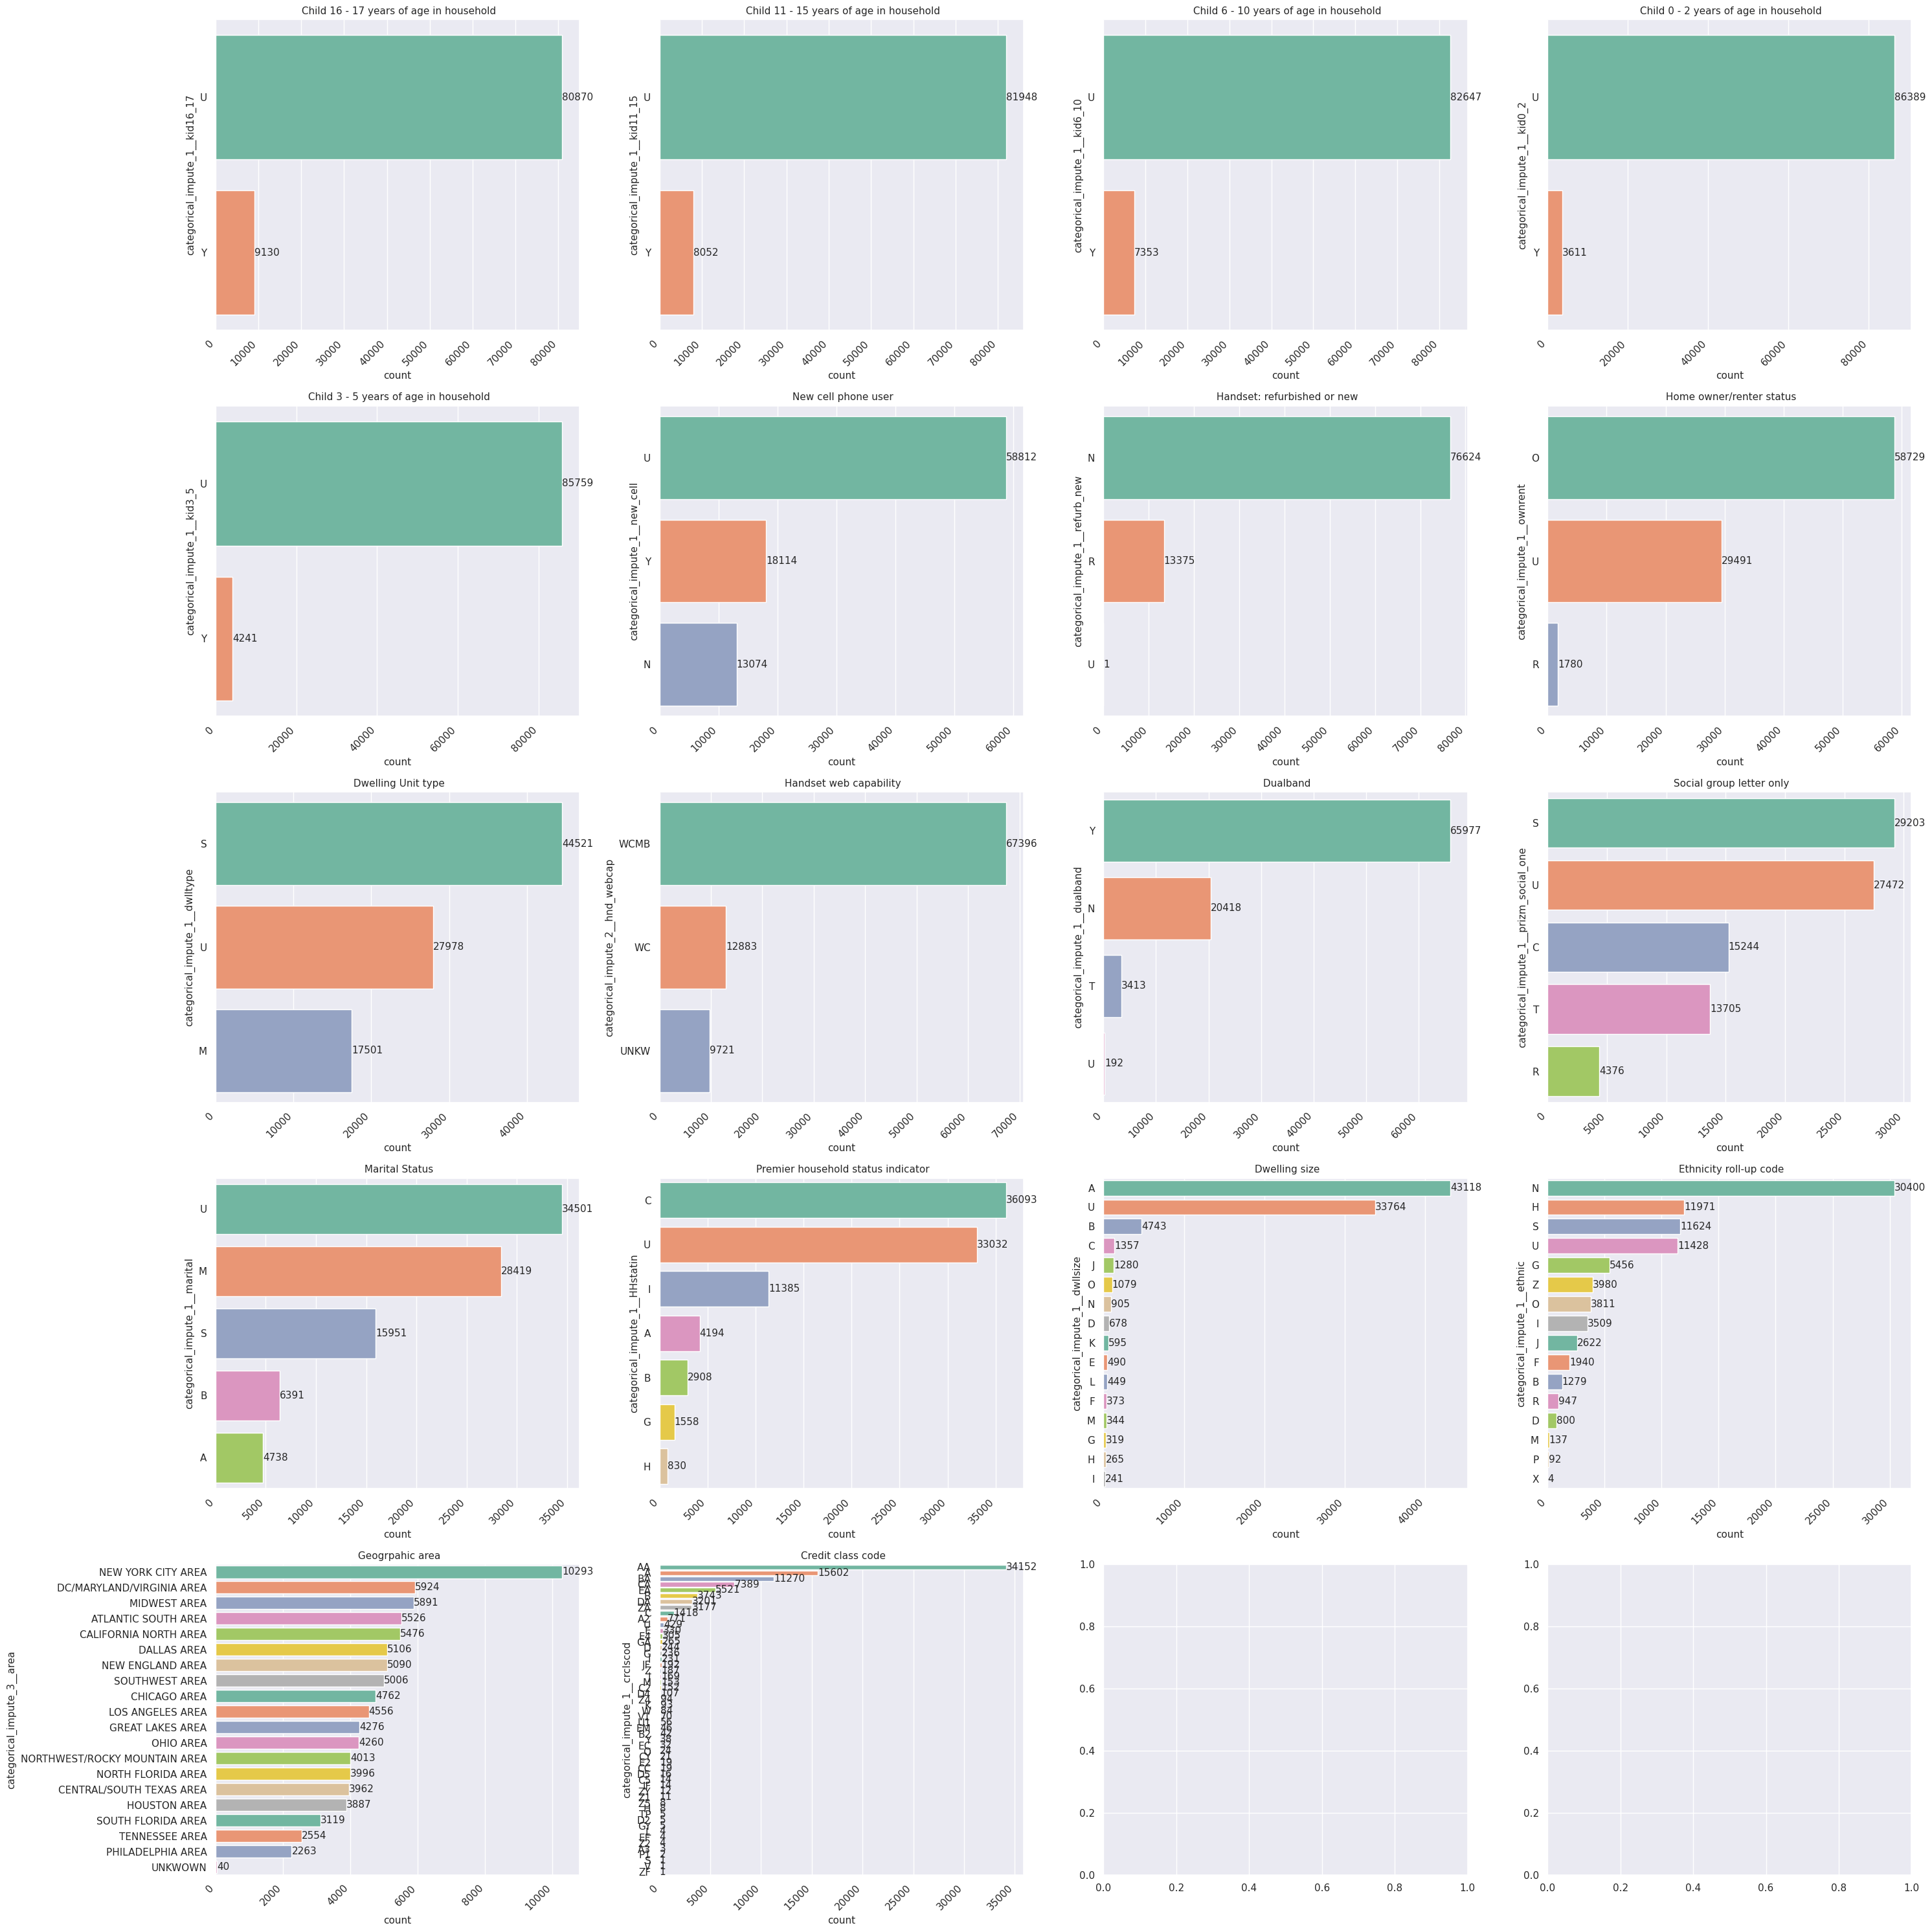

In [323]:
lista_countplot = lcat_impute_U + lcat_impute_UNKW + lcat_impute_UNKWOWN

countplot_categorica_all_2(df_telecom4, lista_countplot)

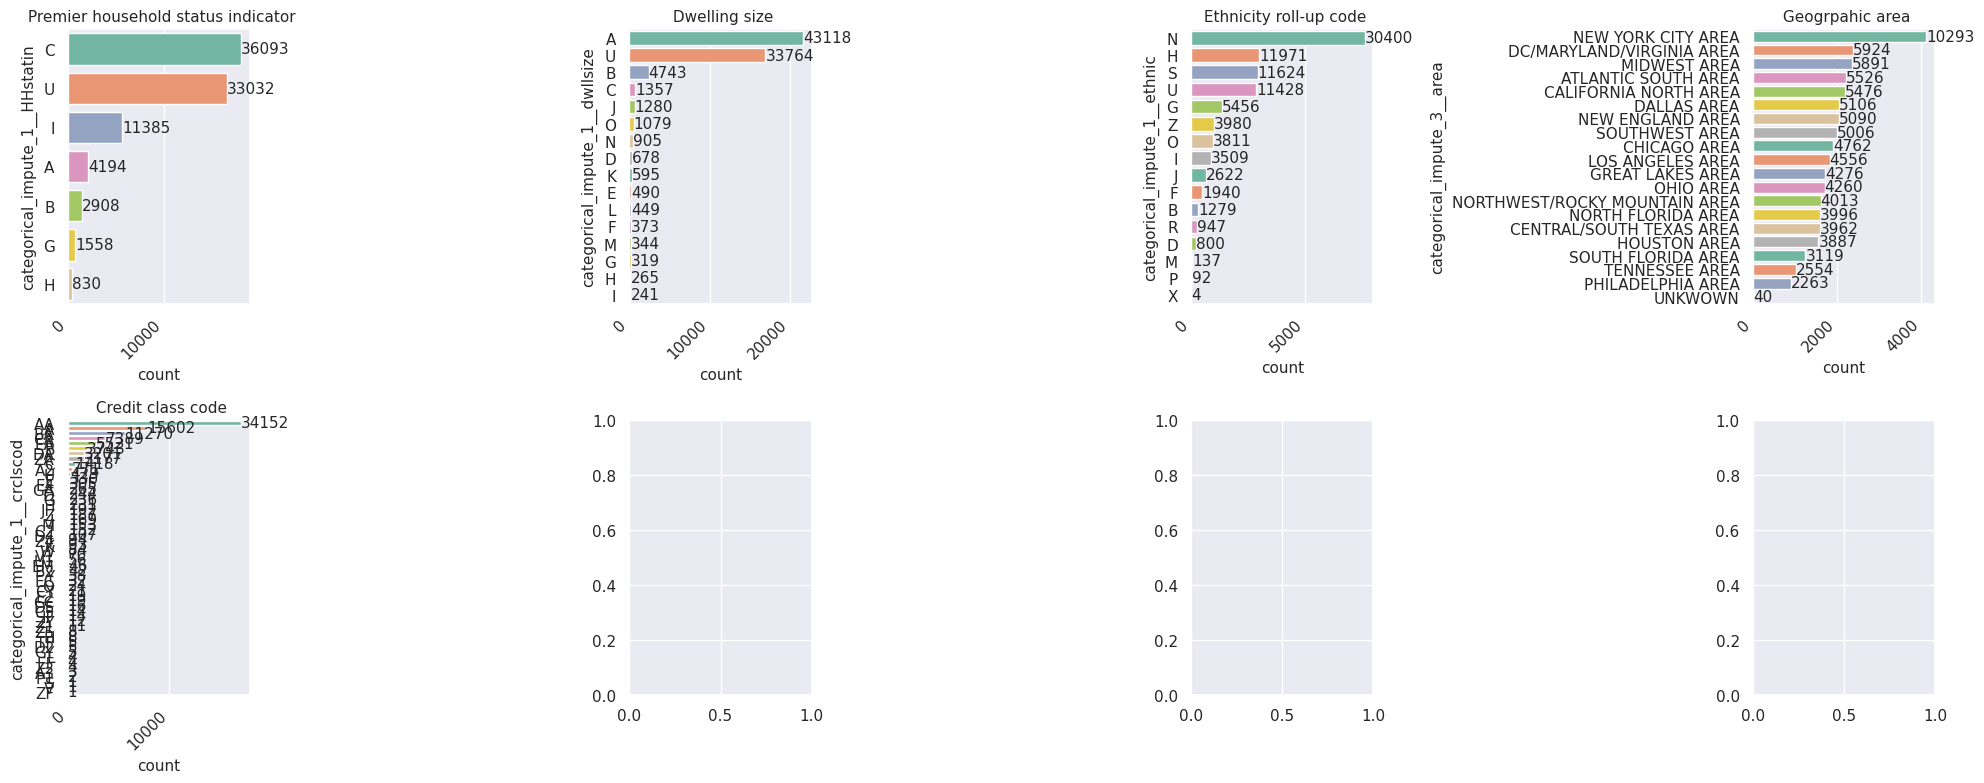

In [324]:
# para los categoricos con alta cardinalidad hay que agrupar para reducir la misma

lista_countplot_agrupar = ['categorical_impute_1__dwllsize', 'categorical_impute_1__ethnic', 'categorical_impute_3__area', 'categorical_impute_1__crclscod', 'categorical_impute_1__HHstatin']

countplot_categorica_all_2(df_telecom4, lista_countplot_agrupar, size_fig=(20,8))

In [325]:
# creamos una funcion para agrupar categoricas debajo de cierto umbral
# limite: valor del umbral por el cual queremos agrupar (agrupamos cuando conteo < umbral)
# former_null: en caso de que haya un valor que represente nulos y caiga dentro del umbral y no querramos agrupar

def agrupacion_categorica(dataset, column, limite, new_value, former_null = ''):

    """
    Funcion que realiza agrupacion categorica
    en base a la columna, limite y nuevo valor.
    """

    value_counts = dataset[column].value_counts(dropna=False)
    values_to_replace = value_counts[value_counts < limite ].index

    for i in values_to_replace:
        if i == former_null:
            pass
        else:
            dataset[column] = np.where(dataset[column] == i, new_value, dataset[column])

In [326]:
# columna 'categorical_impute_1__dwllsize'

value_counts = df_telecom4['categorical_impute_1__dwllsize'].value_counts(dropna=False)
values_to_replace_dwllsize = list(value_counts[value_counts < 1000 ].index)

values_to_replace_dwllsize

['N', 'D', 'K', 'E', 'L', 'F', 'M', 'G', 'H', 'I']

In [327]:
agrupacion_categorica(df_telecom4, 'categorical_impute_1__dwllsize', 1000, 'Ot', former_null = 'U')

print(f"Se han agrupado los siguientes valores {values_to_replace_dwllsize} a 'Ot' para las siguientes columnas: 'categorical_impute_1__dwllsize'")

Se han agrupado los siguientes valores ['N', 'D', 'K', 'E', 'L', 'F', 'M', 'G', 'H', 'I'] a 'Ot' para las siguientes columnas: 'categorical_impute_1__dwllsize'


In [328]:
# columna 'categorical_impute_1__ethnic'

value_counts = df_telecom4['categorical_impute_1__ethnic'].value_counts(dropna=False)
values_to_replace_ethnic = list(value_counts[value_counts < 2500 ].index)

values_to_replace_ethnic

['F', 'B', 'R', 'D', 'M', 'P', 'X']

In [329]:
agrupacion_categorica(df_telecom4, 'categorical_impute_1__ethnic', 1000, 'Ot', former_null = 'U')

print(f"Se han agrupado los siguientes valores {values_to_replace_ethnic} a 'Ot' para las siguientes columnas: 'categorical_impute_1__ethnic'")

Se han agrupado los siguientes valores ['F', 'B', 'R', 'D', 'M', 'P', 'X'] a 'Ot' para las siguientes columnas: 'categorical_impute_1__ethnic'


In [330]:
# columna 'categorical_impute_1__crclscod'

value_counts = df_telecom4['categorical_impute_1__crclscod'].value_counts(dropna=False)
value_counts

AA    34152
A     15602
BA    11270
CA     7389
EA     5521
B      3743
DA     3201
ZA     3177
C      1418
A2      771
U       429
E       330
E4      305
GA      265
D       244
G       236
I       231
JF      192
Z       187
J       169
M       153
C2      152
D4      107
Z4       94
K        93
W        84
V1       70
U1       56
EM       46
B2       42
Y        38
EC       32
O        24
CY       21
E2       19
CC       19
D5       16
C5       14
IF       14
ZY       12
Z1       11
Z5        8
H         8
TP        5
D2        5
GY        5
L         4
EF        4
Z2        4
A3        3
P1        2
S         1
V         1
ZF        1
Name: categorical_impute_1__crclscod, dtype: int64

In [331]:
# columna 'categorical_impute_1__crclscod'

value_counts = df_telecom4['categorical_impute_1__crclscod'].value_counts(dropna=False)
values_to_replace_crclscod = list(value_counts[value_counts < 400 ].index)

values_to_replace_crclscod

['E',
 'E4',
 'GA',
 'D',
 'G',
 'I',
 'JF',
 'Z',
 'J',
 'M',
 'C2',
 'D4',
 'Z4',
 'K',
 'W',
 'V1',
 'U1',
 'EM',
 'B2',
 'Y',
 'EC',
 'O',
 'CY',
 'E2',
 'CC',
 'D5',
 'C5',
 'IF',
 'ZY',
 'Z1',
 'Z5',
 'H',
 'TP',
 'D2',
 'GY',
 'L',
 'EF',
 'Z2',
 'A3',
 'P1',
 'S',
 'V',
 'ZF']

In [332]:
agrupacion_categorica(df_telecom4, 'categorical_impute_1__crclscod', 400, 'Ot', former_null = 'U')

print(f"Se han agrupado los siguientes valores {values_to_replace_crclscod} a 'Ot' para las siguientes columnas: 'categorical_impute_1__crclscod'")

Se han agrupado los siguientes valores ['E', 'E4', 'GA', 'D', 'G', 'I', 'JF', 'Z', 'J', 'M', 'C2', 'D4', 'Z4', 'K', 'W', 'V1', 'U1', 'EM', 'B2', 'Y', 'EC', 'O', 'CY', 'E2', 'CC', 'D5', 'C5', 'IF', 'ZY', 'Z1', 'Z5', 'H', 'TP', 'D2', 'GY', 'L', 'EF', 'Z2', 'A3', 'P1', 'S', 'V', 'ZF'] a 'Ot' para las siguientes columnas: 'categorical_impute_1__crclscod'


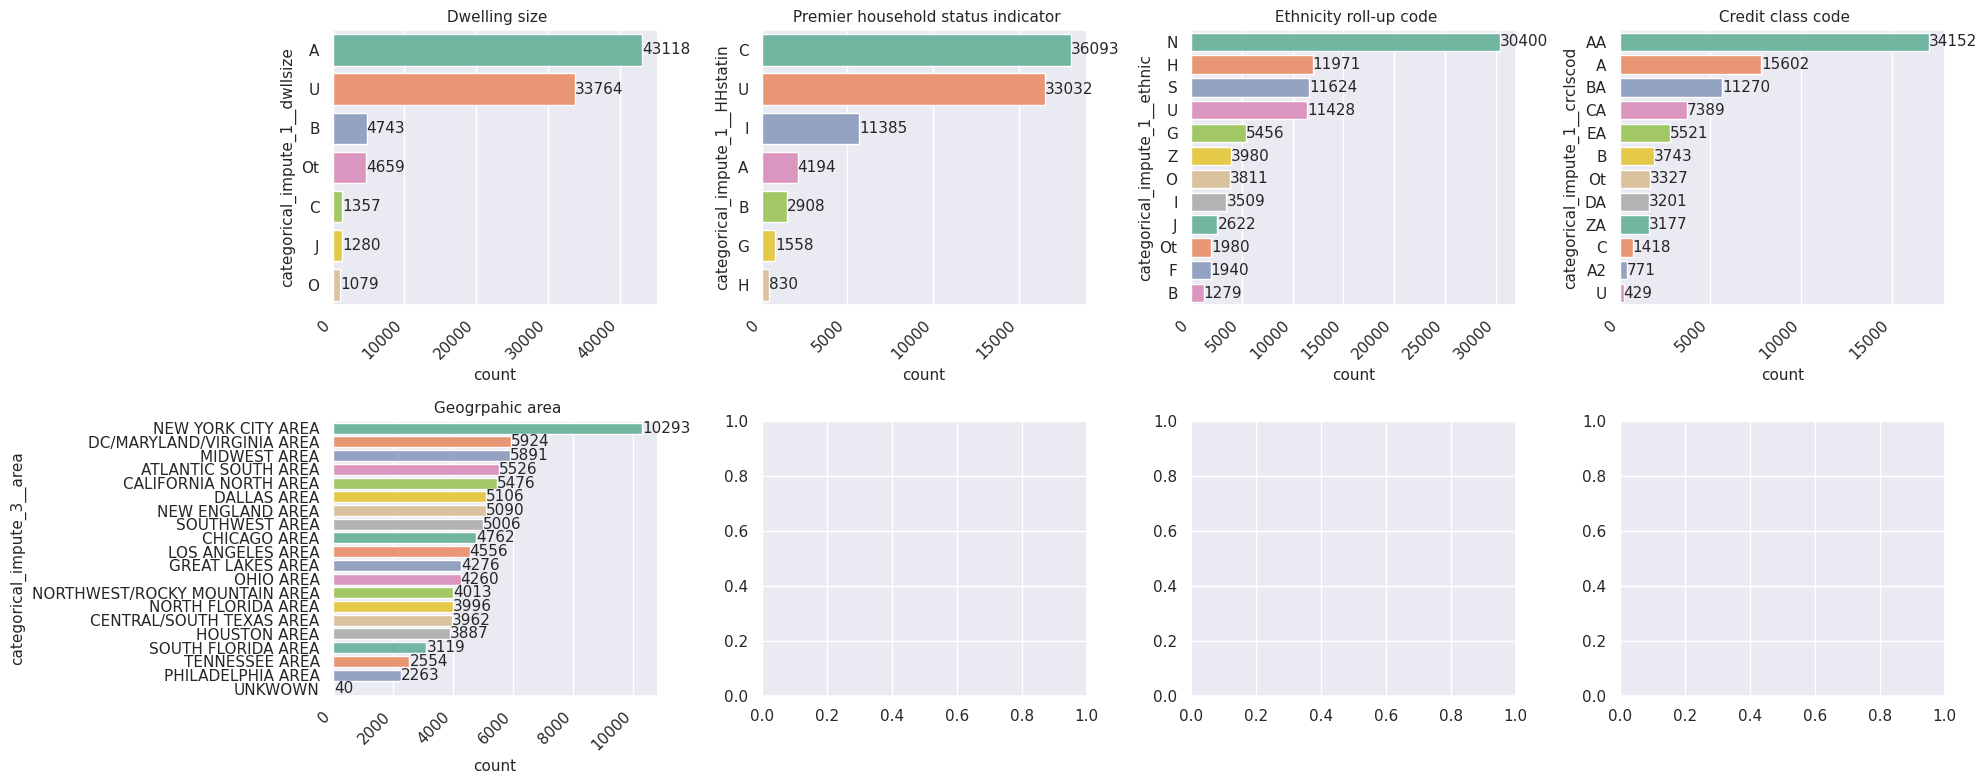

In [333]:
# chequeamos las nuevas distribuciones para los categoricos con alta cardinalidad agrupados

lista_countplot_agrupar = ['categorical_impute_1__dwllsize', 'categorical_impute_1__ethnic', 'categorical_impute_3__area', 'categorical_impute_1__crclscod', 'categorical_impute_1__HHstatin']

countplot_categorica_all_2(df_telecom4, lista_countplot_agrupar, size_fig=(20,8))

In [334]:
ct_preprocess_encoding = ColumnTransformer(
    transformers = [
            #("scale_numeric_columns", StandardScaler(), lista_imputar_numerico_impute),
            ("oe_cat_1", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), lista_imputar_categorico_impute_U),
            ("oe_cat_2", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), lista_imputar_categorico_impute_UNKW),
            ("oe_cat_3", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), lista_imputar_categorico_impute_UNKWOWN),
            ("oe_bool", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), lista_imputar_booleano_impute)
        ],
    remainder='passthrough'
)

df_telecom4 = ct_preprocess_encoding.fit_transform(df_telecom4)

In [335]:
ct_preprocess_encoding

ColumnTransformer(remainder='passthrough',
                  transformers=[('oe_cat_1',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['categorical_impute_1__new_cell',
                                  'categorical_impute_1__crclscod',
                                  'categorical_impute_1__prizm_social_one',
                                  'categorical_impute_1__dualband',
                                  'categorical_impute_1__refurb_new',
                                  'categorical_impute_1__ownrent',
                                  'categorical_im...
                                               sparse_output=False),
                                 ['categorical_impute_2__hnd_webcap']),
                                ('oe_cat_3',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['categorical_impute_3__area']),
                                ('oe_bool',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['boolean_impute__truck', 'boolean_impute__rv',
                                  'boolean_impute__forgntvl',
                                  'boolean_impute__creditcd',
                                  'boolean_impute__asl_flag'])])

In [336]:
pipe = Pipeline(
    steps = [
        ("impute", impute_pipe),
        ("encode", ct_preprocess_encoding)
    ]
)

pipe

Pipeline(steps=[('impute',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_impute',
                                                  SimpleImputer(fill_value=-999,
                                                                strategy='constant'),
                                                  ['rev', 'mou', 'totmrc', 'da',
                                                   'ovrmou', 'ovrrev', 'vceovr',
                                                   'datovr', 'roam',
                                                   'change_mou', 'change_rev',
                                                   'drop_vce', 'drop_dat',
                                                   'blck_vce', 'blck_dat',
                                                   'unan_vce', 'unan_dat',
                                                   'plcd_vce', 'plcd_dat',
                                                   'recv_vce', 'rec...
                                                                sparse_output=False),
                                                  ['categorical_impute_2__hnd_webcap']),
                                                 ('oe_cat_3',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['categorical_impute_3__area']),
                                                 ('oe_bool',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['boolean_impute__truck',
                                                   'boolean_impute__rv',
                                                   'boolean_impute__forgntvl',
                                                   'boolean_impute__creditcd',
                                                   'boolean_impute__asl_flag'])]))])

In [337]:
df_telecom4.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 90000 entries, 1000001 to 1090000
Columns: 186 entries, oe_cat_1__categorical_impute_1__new_cell_N to remainder__remainder__churn
dtypes: float64(185), int64(1)
memory usage: 128.4 MB


# Eliminar alta correlación

* Analizar variables (X) altamente correlacionadas
* Eliminar una variable de cada pareja altamente correlacionada (>95% o >99%...) en el dataset (df)

In [338]:
df_telecom5 = df_telecom4.copy()

In [339]:
#actualizamos nuestra lista de variables

lnum_impute_encode =  ['remainder__' + item for item in lnum_impute]

lcat_impute_encode_U = ['oe_cat_1__' + item for item in lcat_impute_U]
lcat_impute_encode_UNKW = ['oe_cat_2__' + item for item in lcat_impute_UNKW]
lcat_impute_encode_UNKWOWN = ['oe_cat_3__' + item for item in lcat_impute_UNKWOWN]

lbool_impute_encode = ['oe_bool__' + item for item in lbool_impute]

In [340]:
#actualizamos nuestra lista de variables

lista_imputar_numerico_impute_encode = ['remainder__' + item for item in lista_imputar_numerico_impute]

lista_imputar_categorico_impute_encode_U = ['oe_cat_1__' + item for item in lista_imputar_categorico_impute_U]
lista_imputar_categorico_impute_encode_UNKW = ['oe_cat_2__' + item for item in lista_imputar_categorico_impute_UNKW]
lista_imputar_categorico_impute_encode_UNKWOWN = ['oe_cat_3__' + item for item in lista_imputar_categorico_impute_UNKWOWN]

lista_imputar_booleano_impute_encode = ['oe_bool__' + item for item in lista_imputar_booleano_impute]

In [341]:
len(lista_imputar_numerico_impute_encode)

74

In [342]:
len(lista_imputar_numerico_impute)

74

In [343]:
df_desc_clean_impute_encode = df_desc_clean_impute.copy()

In [344]:
list_to_replace = lista_imputar_numerico_impute_encode
list_to_search = lista_imputar_numerico_impute

for i in list_to_replace:

    indice_final = list_to_replace.index(i)
    valor_final = list_to_replace[indice_final]

    valor_buscar = list_to_search[indice_final]

    df_desc_clean_impute_encode['Variable'] = np.where(df_desc_clean_impute_encode['Variable'] == valor_buscar, valor_final , df_desc_clean_impute_encode['Variable'])

In [345]:
list_to_replace = lista_imputar_categorico_impute_encode_U
list_to_search = lista_imputar_categorico_impute_U

for i in list_to_replace:

    indice_final = list_to_replace.index(i)
    valor_final = list_to_replace[indice_final]

    valor_buscar = list_to_search[indice_final]

    df_desc_clean_impute_encode['Variable'] = np.where(df_desc_clean_impute_encode['Variable'] == valor_buscar, valor_final , df_desc_clean_impute_encode['Variable'])

In [346]:
list_to_replace = lista_imputar_categorico_impute_encode_UNKW
list_to_search = lista_imputar_categorico_impute_UNKW

for i in list_to_replace:

    indice_final = list_to_replace.index(i)
    valor_final = list_to_replace[indice_final]

    valor_buscar = list_to_search[indice_final]

    df_desc_clean_impute_encode['Variable'] = np.where(df_desc_clean_impute_encode['Variable'] == valor_buscar, valor_final , df_desc_clean_impute_encode['Variable'])

In [347]:
list_to_replace = lista_imputar_categorico_impute_encode_UNKWOWN
list_to_search = lista_imputar_categorico_impute_UNKWOWN

for i in list_to_replace:

    indice_final = list_to_replace.index(i)
    valor_final = list_to_replace[indice_final]

    valor_buscar = list_to_search[indice_final]

    df_desc_clean_impute_encode['Variable'] = np.where(df_desc_clean_impute_encode['Variable'] == valor_buscar, valor_final , df_desc_clean_impute_encode['Variable'])

In [348]:
list_to_replace = lista_imputar_booleano_impute_encode
list_to_search = lista_imputar_booleano_impute

for i in list_to_replace:

    indice_final = list_to_replace.index(i)
    valor_final = list_to_replace[indice_final]

    valor_buscar = list_to_search[indice_final]

    df_desc_clean_impute_encode['Variable'] = np.where(df_desc_clean_impute_encode['Variable'] == valor_buscar, valor_final , df_desc_clean_impute_encode['Variable'])

In [349]:
df_desc_clean_impute_encode['Variable'] = np.where(df_desc_clean_impute_encode['Variable'] == 'remainder__churn', 'remainder__remainder__churn', df_desc_clean_impute_encode['Variable'])

In [350]:
df_desc_clean_impute_encode['Variable'].unique()

array(['remainder__numeric_impute__rev', 'remainder__numeric_impute__mou',
       'remainder__numeric_impute__totmrc',
       'remainder__numeric_impute__da',
       'remainder__numeric_impute__ovrmou',
       'remainder__numeric_impute__ovrrev',
       'remainder__numeric_impute__vceovr',
       'remainder__numeric_impute__datovr',
       'remainder__numeric_impute__roam',
       'remainder__numeric_impute__change_mou',
       'remainder__numeric_impute__change_rev',
       'remainder__numeric_impute__drop_vce',
       'remainder__numeric_impute__drop_dat',
       'remainder__numeric_impute__blck_vce',
       'remainder__numeric_impute__blck_dat',
       'remainder__numeric_impute__unan_vce',
       'remainder__numeric_impute__unan_dat',
       'remainder__numeric_impute__plcd_vce',
       'remainder__numeric_impute__plcd_dat',
       'remainder__numeric_impute__recv_vce',
       'remainder__numeric_impute__recv_sms',
       'remainder__numeric_impute__comp_vce',
       'remainder__nu

In [351]:
df_telecom5.head()

,oe_cat_1__categorical_impute_1__new_cell_N,oe_cat_1__categorical_impute_1__new_cell_U,oe_cat_1__categorical_impute_1__new_cell_Y,oe_cat_1__categorical_impute_1__crclscod_A,oe_cat_1__categorical_impute_1__crclscod_A2,oe_cat_1__categorical_impute_1__crclscod_AA,oe_cat_1__categorical_impute_1__crclscod_B,oe_cat_1__categorical_impute_1__crclscod_BA,oe_cat_1__categorical_impute_1__crclscod_C,oe_cat_1__categorical_impute_1__crclscod_CA,...,remainder__numeric_impute__avg6rev,remainder__numeric_impute__hnd_price,remainder__numeric_impute__phones,remainder__numeric_impute__models,remainder__numeric_impute__lor,remainder__numeric_impute__adults,remainder__numeric_impute__income,remainder__numeric_impute__numbcars,remainder__numeric_impute__eqpdays,remainder__remainder__churn
Customer_ID,,,,,,,,,,,,,,,,,,,,,
1000001,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,38.0,149.98999,2.0,2.0,15.0,1.0,4.0,3.0,361.0,1
1000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,48.0,-999.00000,7.0,6.0,1.0,1.0,5.0,1.0,240.0,0
1000003,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,17.0,29.98999,2.0,1.0,7.0,2.0,5.0,2.0,1504.0,1
1000004,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,40.0,29.98999,1.0,1.0,6.0,4.0,6.0,1.0,1812.0,0
1000005,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,80.0,149.98999,6.0,4.0,5.0,1.0,6.0,1.0,434.0,0


In [352]:
target = 'remainder__remainder__churn'
features = df_telecom5.columns[df_telecom5.columns!=target]

# Divide dataset en matriz de variables (X) y output (y)
X = df_telecom5[features]
y = df_telecom5[target]

In [353]:
def highly_correlated(X, y, threshold):
    col_corr = list() # Set of all the names of deleted columns
    colnames = list()
    rownames = list()
    corr_matrix = X.corr().abs()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if (corr_matrix.iloc[i, j] >= threshold) and (corr_matrix.columns[j] not in col_corr):
                colnames.append(corr_matrix.columns[i]) # getting the name of column
                rownames.append(corr_matrix.index[j])
                col_corr.append(corr_matrix.iloc[i, j])
    Z = pd.DataFrame({'F1':colnames,
                      'F2':rownames,
                      'corr_F1_F2':col_corr,
                      'corr_F1_target': [np.abs(np.corrcoef(X[i],y)[0,1]) for i in colnames],
                      'corr_F2_target': [np.abs(np.corrcoef(X[i],y)[0,1]) for i in rownames]
                      })
    Z['F_to_delete'] = rownames
    Z['F_to_delete'][Z['corr_F1_target'] < Z['corr_F2_target']] = Z['F1'][Z['corr_F1_target'] < Z['corr_F2_target']]

    return Z

highly_corr = highly_correlated(X,y,0.95)
highly_corr

,F1,F2,corr_F1_F2,corr_F1_target,corr_F2_target,F_to_delete
0,oe_cat_1__categorical_impute_1__refurb_new_R,oe_cat_1__categorical_impute_1__refurb_new_N,0.999956,0.029593,0.029560,oe_cat_1__categorical_impute_1__refurb_new_N
1,oe_cat_1__categorical_impute_1__ownrent_U,oe_cat_1__categorical_impute_1__ownrent_O,0.956732,0.027245,0.028545,oe_cat_1__categorical_impute_1__ownrent_U
2,oe_cat_1__categorical_impute_1__kid0_2_Y,oe_cat_1__categorical_impute_1__kid0_2_U,1.000000,0.009219,0.009219,oe_cat_1__categorical_impute_1__kid0_2_U
3,oe_cat_1__categorical_impute_1__kid3_5_Y,oe_cat_1__categorical_impute_1__kid3_5_U,1.000000,0.005748,0.005748,oe_cat_1__categorical_impute_1__kid3_5_U
4,oe_cat_1__categorical_impute_1__kid6_10_Y,oe_cat_1__categorical_impute_1__kid6_10_U,1.000000,0.003072,0.003072,oe_cat_1__categorical_impute_1__kid6_10_U
5,oe_cat_1__categorical_impute_1__kid11_15_Y,oe_cat_1__categorical_impute_1__kid11_15_U,1.000000,0.003393,0.003393,oe_cat_1__categorical_impute_1__kid11_15_U
6,oe_cat_1__categorical_impute_1__kid16_17_Y,oe_cat_1__categorical_impute_1__kid16_17_U,1.000000,0.004405,0.004405,oe_cat_1__categorical_impute_1__kid16_17_U
7,oe_bool__boolean_impute__truck_1.0,oe_bool__boolean_impute__truck_0.0,0.951214,0.008077,0.008789,oe_bool__boolean_impute__truck_1.0
8,oe_bool__boolean_impute__rv_-1.0,oe_bool__boolean_impute__truck_-1.0,1.000000,0.003070,0.003070,oe_bool__boolean_impute__truck_-1.0
9,oe_bool__boolean_impute__forgntvl_-1.0,oe_bool__boolean_impute__truck_-1.0,1.000000,0.003070,0.003070,oe_bool__boolean_impute__truck_-1.0


In [354]:
columnas_a_eliminar_high_correlation = list(highly_corr['F_to_delete'])

df_telecom5.drop(list(highly_corr['F_to_delete']), axis='columns', inplace=True)

print(f"Se han eliminado las siguientes columnas debido a alta correlación: {columnas_a_eliminar_high_correlation}")

Se han eliminado las siguientes columnas debido a alta correlación: ['oe_cat_1__categorical_impute_1__refurb_new_N', 'oe_cat_1__categorical_impute_1__ownrent_U', 'oe_cat_1__categorical_impute_1__kid0_2_U', 'oe_cat_1__categorical_impute_1__kid3_5_U', 'oe_cat_1__categorical_impute_1__kid6_10_U', 'oe_cat_1__categorical_impute_1__kid11_15_U', 'oe_cat_1__categorical_impute_1__kid16_17_U', 'oe_bool__boolean_impute__truck_1.0', 'oe_bool__boolean_impute__truck_-1.0', 'oe_bool__boolean_impute__truck_-1.0', 'oe_bool__boolean_impute__rv_-1.0', 'oe_bool__boolean_impute__truck_-1.0', 'oe_bool__boolean_impute__rv_-1.0', 'oe_bool__boolean_impute__forgntvl_-1.0', 'oe_bool__boolean_impute__creditcd_1.0', 'oe_bool__boolean_impute__asl_flag_0.0', 'remainder__numeric_impute__ovrrev', 'remainder__numeric_impute__datovr', 'remainder__numeric_impute__plcd_vce', 'remainder__numeric_impute__comp_dat', 'remainder__numeric_impute__cc_mou', 'remainder__numeric_impute__inonemin', 'remainder__numeric_impute__mou_op

# Eliminar baja varianza

* Eliminar variables (X) practicamente constantes con un threshold minimo (1% o menos)

In [355]:
df_telecom6 = df_telecom5.copy()

In [356]:
target = 'remainder__remainder__churn'
features = df_telecom6.columns[df_telecom6.columns!=target]

# Divide dataset en matriz de variables (X) y output (y)
X = df_telecom6[features]
y = df_telecom6[target]

In [357]:
# Eliminamos columnas practicamente constantes (nula varianza)
vt = VarianceThreshold(threshold = 0.01)
vt.fit(X)

cols_lowvar = X.columns[vt.get_support()==False]
X.drop(columns=cols_lowvar,inplace=True)

print(len(cols_lowvar),' low variance features were removed:\n', cols_lowvar.to_list())

5  low variance features were removed:
 ['oe_cat_1__categorical_impute_1__crclscod_A2', 'oe_cat_1__categorical_impute_1__crclscod_U', 'oe_cat_1__categorical_impute_1__dualband_U', 'oe_cat_1__categorical_impute_1__HHstatin_H', 'oe_cat_3__categorical_impute_3__area_UNKWOWN']


# Guardar clean data

* Guardar en data path y mostrar el resultado en un head()

In [358]:
CWD = os.getcwd()

DATA_PATH = os.path.join(CWD, '/content/drive/MyDrive/EJERCICIO-ML-Sup/data')

df_telecom6.to_pickle(os.path.join(DATA_PATH, 'dataset_clean'))

In [359]:
df_telecom6.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 90000 entries, 1000001 to 1090000
Data columns (total 158 columns):
 #    Column                                                              Non-Null Count  Dtype  
---   ------                                                              --------------  -----  
 0    oe_cat_1__categorical_impute_1__new_cell_N                          90000 non-null  float64
 1    oe_cat_1__categorical_impute_1__new_cell_U                          90000 non-null  float64
 2    oe_cat_1__categorical_impute_1__new_cell_Y                          90000 non-null  float64
 3    oe_cat_1__categorical_impute_1__crclscod_A                          90000 non-null  float64
 4    oe_cat_1__categorical_impute_1__crclscod_A2                         90000 non-null  float64
 5    oe_cat_1__categorical_impute_1__crclscod_AA                         90000 non-null  float64
 6    oe_cat_1__categorical_impute_1__crclscod_B                          90000 non-null  float64


In [360]:
df_telecom6.shape

(90000, 158)

In [361]:
df_telecom6.isnull().sum().sum()

0

In [362]:
df_telecom6.head()

,oe_cat_1__categorical_impute_1__new_cell_N,oe_cat_1__categorical_impute_1__new_cell_U,oe_cat_1__categorical_impute_1__new_cell_Y,oe_cat_1__categorical_impute_1__crclscod_A,oe_cat_1__categorical_impute_1__crclscod_A2,oe_cat_1__categorical_impute_1__crclscod_AA,oe_cat_1__categorical_impute_1__crclscod_B,oe_cat_1__categorical_impute_1__crclscod_BA,oe_cat_1__categorical_impute_1__crclscod_C,oe_cat_1__categorical_impute_1__crclscod_CA,...,remainder__numeric_impute__avg6qty,remainder__numeric_impute__avg6rev,remainder__numeric_impute__hnd_price,remainder__numeric_impute__phones,remainder__numeric_impute__lor,remainder__numeric_impute__adults,remainder__numeric_impute__income,remainder__numeric_impute__numbcars,remainder__numeric_impute__eqpdays,remainder__remainder__churn
Customer_ID,,,,,,,,,,,,,,,,,,,,,
1000001,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,136.0,38.0,149.98999,2.0,15.0,1.0,4.0,3.0,361.0,1
1000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,275.0,48.0,-999.00000,7.0,1.0,1.0,5.0,1.0,240.0,0
1000003,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,6.0,17.0,29.98999,2.0,7.0,2.0,5.0,2.0,1504.0,1
1000004,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,25.0,40.0,29.98999,1.0,6.0,4.0,6.0,1.0,1812.0,0
1000005,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,196.0,80.0,149.98999,6.0,5.0,1.0,6.0,1.0,434.0,0


In [363]:
# guardamos la lista de valores boolean a corregir

CWD = os.getcwd()

DATA_PATH = os.path.join(CWD, "/content/drive/MyDrive/EJERCICIO-ML-Sup/model")

with open(os.path.join(DATA_PATH, 'Lista_limpieza_valores_boolean.joblib'), 'wb') as io:
    dill.dump(Lista_limpieza_valores_boolean ,io)

In [364]:
# guardamos la funcion de valores boolean a corregir

CWD = os.getcwd()

DATA_PATH = os.path.join(CWD, "/content/drive/MyDrive/EJERCICIO-ML-Sup/model")

with open(os.path.join(DATA_PATH, 'limpieza_valores_boolean.joblib'), 'wb') as io:
    dill.dump(limpieza_valores_boolean ,io)

In [365]:
# guardamos la función de negative_eqp_days_function

CWD = os.getcwd()

DATA_PATH = os.path.join(CWD, "/content/drive/MyDrive/EJERCICIO-ML-Sup/model")

with open(os.path.join(DATA_PATH, 'negative_eqp_days_function.joblib'), 'wb') as io:
    dill.dump(negative_eqp_days_function ,io)

In [366]:
# guardamos la moda de la función de negative_eqp_days_function

CWD = os.getcwd()

DATA_PATH = os.path.join(CWD, "/content/drive/MyDrive/EJERCICIO-ML-Sup/model")

with open(os.path.join(DATA_PATH, 'moda.joblib'), 'wb') as io:
    dill.dump(moda ,io)

In [367]:
# guardamos la lista de agrupación de dwllsize

CWD = os.getcwd()

DATA_PATH = os.path.join(CWD, "/content/drive/MyDrive/EJERCICIO-ML-Sup/model")

with open(os.path.join(DATA_PATH, 'values_to_replace_dwllsize.joblib'), 'wb') as io:
    dill.dump(values_to_replace_dwllsize ,io)

In [368]:
# guardamos la lista de agrupación de ethnic

CWD = os.getcwd()

DATA_PATH = os.path.join(CWD, "/content/drive/MyDrive/EJERCICIO-ML-Sup/model")

with open(os.path.join(DATA_PATH, 'values_to_replace_ethnic.joblib'), 'wb') as io:
    dill.dump(values_to_replace_ethnic ,io)

In [369]:
# guardamos la lista de agrupación de crclscod

CWD = os.getcwd()

DATA_PATH = os.path.join(CWD, "/content/drive/MyDrive/EJERCICIO-ML-Sup/model")

with open(os.path.join(DATA_PATH, 'values_to_replace_crclscod.joblib'), 'wb') as io:
    dill.dump(values_to_replace_crclscod ,io)

In [370]:
CWD = os.getcwd()

DATA_PATH = os.path.join(CWD, "/content/drive/MyDrive/EJERCICIO-ML-Sup/model")

pickle.dump(pipe, open(os.path.join(DATA_PATH, 'pipeline.pkl'), 'wb'))